# Atom loading analysis
Valid for experiments from 2025-06-23 until ...

In the experiment, I measure and save Atom_loading_time only when I load an atom, not in each measurement or each iteration. Since 2025-06-23, I also run measure_Magnetometer, Sampler0_test, and measure_coil_driver once for each atom loading. 

As before, the AOM RF powers are measured when we run the feedback.


In [105]:
print(AZ_bottom_volts_MOT,AZ_top_volts_MOT,AX_volts_MOT,AY_volts_MOT)

print(set_point_PD1_AOM_A1)
print(set_point_PD2_AOM_A2)
print(set_point_PD3_AOM_A3)
print(set_point_PD4_AOM_A4)
print(set_point_PD5_AOM_A5)
print(set_point_PD6_AOM_A6)

6.084410785442844 6.4261470617792975 0.1170570216834137 -0.07582513997256535
0.06
0.104
0.078
0.104
0.078
0.078


In [878]:
date_filters = ["2026-03-03"]

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import csv
import numpy as np
import os,sys
import PIL # for reading tif images
import h5py
import datetime as dt
import time
from scipy.optimize import curve_fit
from skimage.filters import threshold_otsu
from IPython.display import display, HTML ## for large prints
import math
import itertools

sys.path.append("..\\")
from h5_data_utilities import * # helper functions for dealing with h5 files

def average_over_measurement(measurements, history):
    iteration = len(history) // measurements
    mean_by_iteration = [np.mean(history[j * measurements:(j + 1) * measurements]) for j in range(iteration)]
    return mean_by_iteration


fnames = get_files_by_criteria(date_filters, # only find files from these date directories
                               name_filters=["GeneralVariableScan","Microwaves_scans"], # find files containing any of these strings
                               condition=lambda filename: True, # use this to filter by experiment parameters, like this: lambda filename: np.bool_(h5py.File(filename)['datasets']['set_current_coil_volts_at_finish'])
                               start_dir=results,
                               include_path=True, # if False, only return the name of the file, not the full path
                               print_filenames=False
)


only_show_i_greater_than = -1

print(f"found {len(fnames)} files")
for i,f in enumerate(fnames):
    if i > only_show_i_greater_than:
        try:
            ds = h5py.File(os.path.join(results, f))['datasets']
            scan_str = str_from_h5(ds['scan_variable1_name'])
            if str_from_h5(ds['scan_variable2_name']) != '':
                scan_str += ", " +str_from_h5(ds['scan_variable2_name'])
            print(f"file {i} ({f}) scanned over "+scan_str)
        except:

            print(f"oops... something wrong with {f}")

found 21 files
file 0 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-03-03\00\000033964-GeneralVariableScan.h5) scanned over f_microwaves_dds
file 1 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-03-03\00\000033964-GeneralVariableScan_microwave_Rabi_2_scan_over_f_microwaves_dds.h5) scanned over f_microwaves_dds
file 2 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-03-03\01\000033965-GeneralVariableScan.h5) scanned over f_microwaves_dds
file 3 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-03-03\01\000033965-GeneralVariableScan_microwave_Rabi_2_scan_over_f_microwaves_dds.h5) scanned over f_microwaves_dds
file 4 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-03-03\02\000033966-GeneralVariableScan.h5) scanned over f_microwaves_dds
file 5 (C:\Networking Experiment\artiq codes\artiq-master\results\2026-03-03\02\000033966-GeneralVariableScan_microwave_Rabi_2_scan_over_f_microwaves_dds.h5) scanned over f_micr

## Combine files - Fitting resonance dip

experiment: microwave_Rabi_2_experiment
override: {'t_FORT_drop':0.0*us, 'f_microwaves_dds':(336.91)*MHz,'AY_volts_microwave':3.23,'t_microwave_pulse':13.0*us}
# of iterations:  50
center=336976273.2404, sigma=23104.6038, depth=0.6272


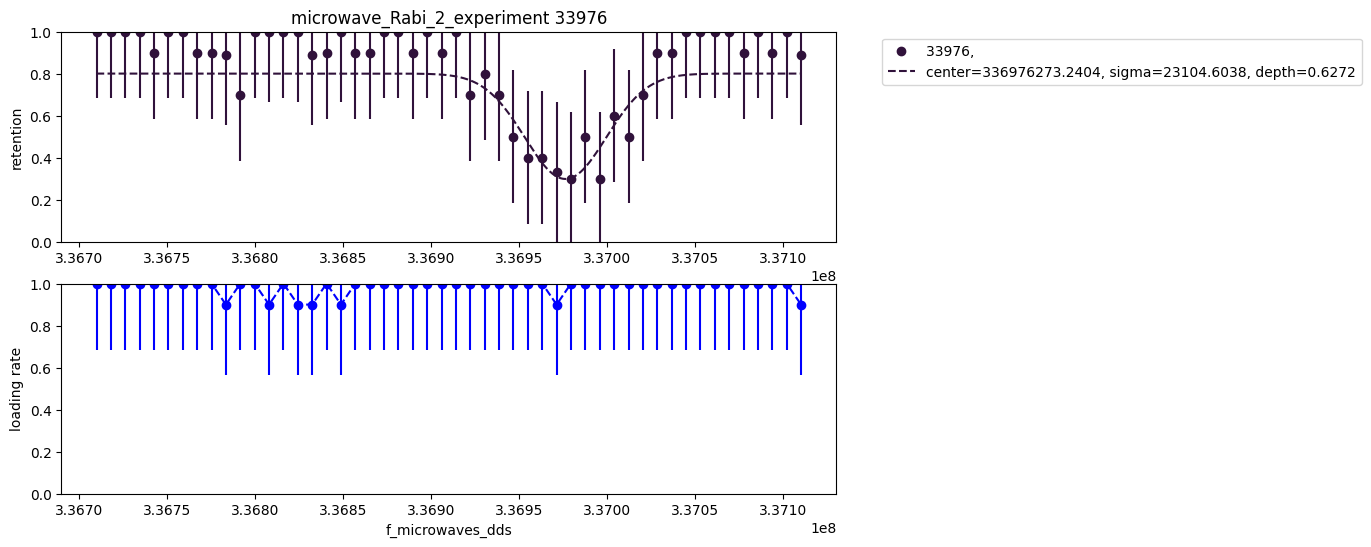

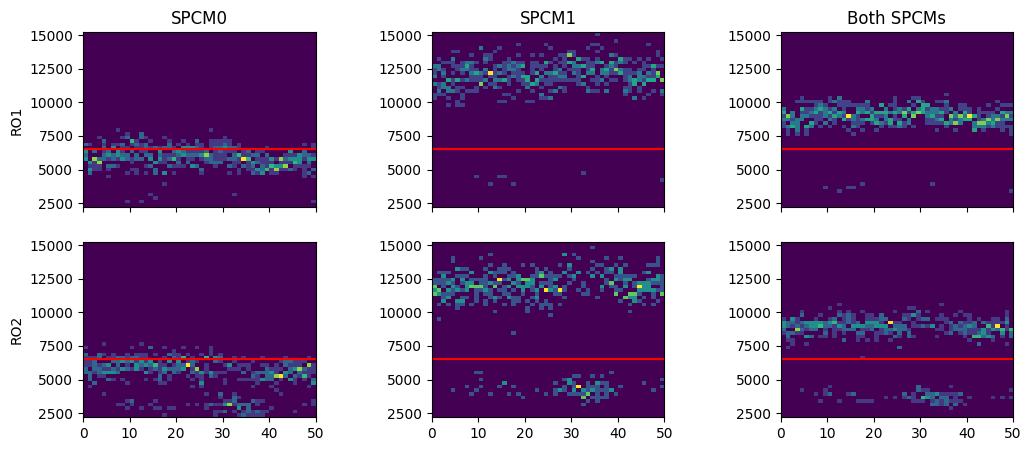

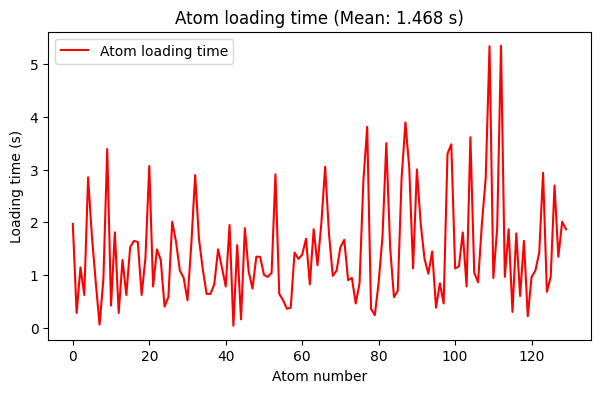

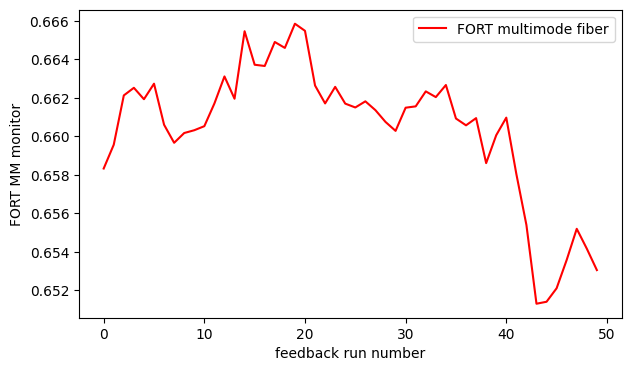

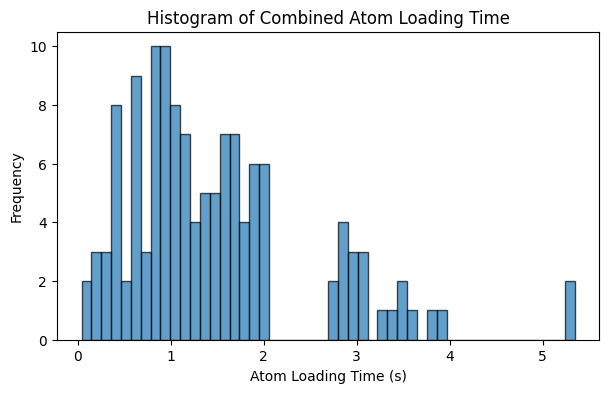

In [879]:
"""
With fitting the resonance for microwave scans

"""
### the file(s) to analyze:
file_indices = {
    19:'',
    # 45:'',
    # 47:'',
    # 49:'',
    # 51:'',
} 

# file_indices = {i: '' for i in range(0, 20, 2)}

compare = True # compare multiple files in the same retention and loading plots
otsu_threshold = False # compute threshold using Otsu method instead doing it by eye. only work when require atom loading = False
showhist = True
showloading = True
custom_xlabel = True
merge_data = False # if True, the datasets will be combined, and if fit=True, the new merged data will be fit. don't try this in 2D
fit = True

showhist_counts = False 

# for plotting
legend_vars =[]   #legend_vars = ['AY_volts_OP', 'f_microwaves_dds'] # will be included in the plot legend
xform_and_label = {}
loc='best'
ret_cmap = mpl.colormaps['turbo']
ldng_cmap = mpl.colormaps['winter']

if compare:
    if showloading:
        fig_ret,axes = plt.subplots(nrows=2, sharex=False, figsize=(10, 6))
        ax_ret, ax_ldng = axes
    else:
        fig_ret,ax_ret = plt.subplots()


SPCM0_RO1_hists = []
SPCM0_RO2_hists = []
SPCM1_RO1_hists = []
SPCM1_RO2_hists = []
BothSPCMs_RO1_hists = []
BothSPCMs_RO2_hists = []
mean1_by_iteration = []
mean2_by_iteration = []

merged_retention = np.array([])
merged_scan_sequence1 = np.array([])
merged_errs = np.array([])
rid_str = ''

all_atom_loading_times = []
all_atom_loading_wall_clocks = []

for idx,f_item in enumerate(file_indices.items()):
    f_idx,f_comment = f_item   # idx - f_item = {f_idx: f_comment}
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    print("experiment:",experiment_function)
    print("override:",override_ExperimentVariables)

    iterations = len(scan_sequence1) #int(len(SPCM0_RO1)/n_measurements)
    print("# of iterations: ", iterations)

    all_atom_loading_times.append(Atom_loading_time[1:])
    all_atom_loading_wall_clocks.append(atom_loading_wall_clock[1:])
    
    if otsu_threshold:
        thresh = threshold_otsu(BothSPCMs_RO1)
        print("threshold_otsu: ", thresh)
    else:
        cutoff1 = cutoff2 = single_atom_threshold * t_SPCM_first_shot

    
    ### for plotting 
    ### xsteps_xform is a function that can transform scan_sequence1 for plotting. Here it is equal to identity, i.e. no change in scan_sequence1.
    if scan_variable1_name in xform_and_label and custom_xlabel:
        xsteps_xform, xlabel = (xform_and_label[scan_variable1_name]['xsteps_xform'], xform_and_label[scan_variable1_name]['xlabel'])
    else:
        xsteps_xform, xlabel = (lambda x: x, scan_variable1_name)
        

    legend_string = ''
    for a in legend_vars:
        legend_string += f'{a}={locals()[a]}, '
    legend_string = legend_string[:-2]
    f_comment += legend_string

    
    ### get_loading_and_retention
    ### These array have length = iterations
    retention_array, loading_rate_array, n_atoms_loaded_array = get_loading_and_retention(BothSPCMs_RO1, BothSPCMs_RO2, n_measurements, iterations, cutoff1, otsu=otsu_threshold)


    ### Necessary to analyze data with 2 scan_sequences
    ### reshaping each array into a 2D array with shape = shape, with order = 'F' (Fortran-style) to sort column by column
    
    ncols = len(scan_sequence2)
    nrows = len(scan_sequence1)
    shape = (len(scan_sequence2),len(scan_sequence1))
    loading_rate_raveled = np.reshape(loading_rate_array,shape,order='F') # rows have constant variable2
    n_atoms_loaded_raveled = np.reshape(n_atoms_loaded_array,shape,order='F') # rows have constant variable2
    retention_raveled = np.reshape(retention_array,shape,order='F') # rows have constant variable2

    
    ### show historam of first_shot and second_shot
    histMin = np.min([SPCM0_RO1, SPCM0_RO2, SPCM1_RO1, SPCM1_RO2])/t_SPCM_first_shot ## boundary for the histogram plots
    histMax = np.max([SPCM0_RO1, SPCM0_RO2, SPCM1_RO1, SPCM1_RO2])/t_SPCM_first_shot
    if showhist:
        SPCM0_RO1_hists.append(
            [np.histogram(SPCM0_RO1[i*n_measurements:(i+1)*n_measurements]/t_SPCM_first_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])

        SPCM0_RO2_hists.append(
            [np.histogram(SPCM0_RO2[i*n_measurements:(i+1)*n_measurements]/t_SPCM_second_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])

        SPCM1_RO1_hists.append(
            [np.histogram(SPCM1_RO1[i*n_measurements:(i+1)*n_measurements]/t_SPCM_first_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])

        SPCM1_RO2_hists.append(
            [np.histogram(SPCM1_RO2[i*n_measurements:(i+1)*n_measurements]/t_SPCM_second_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])
        
        BothSPCMs_RO1_hists.append(
            [np.histogram(BothSPCMs_RO1[i*n_measurements:(i+1)*n_measurements]/t_SPCM_first_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])

        BothSPCMs_RO2_hists.append(
            [np.histogram(BothSPCMs_RO2[i*n_measurements:(i+1)*n_measurements]/t_SPCM_second_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])

    
    ### plot a retention curve vs variable 1 for each variable 2 value
    for i, retention, loading, n_loaded, var2 in zip(range(len(scan_sequence2)), retention_raveled, loading_rate_raveled, n_atoms_loaded_raveled, scan_sequence2):
        
        errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
        if not compare:
            if showloading:
                    fig_ret,axes = plt.subplots(nrows=2, sharex=False)
                    ax_ret, ax_ldng = axes
            else:
                fig_ret,ax_ret = plt.subplots()
                
        if not merge_data:
            ax_ret.scatter(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], label=str(rid)+', '+f_comment, color=ret_cmap(idx/len(file_indices)))
            ax_ret.errorbar(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], errs[loading > 0], ls='none',color=ret_cmap(idx/len(file_indices)))
            ax_ret.set_ylim((0,1))

            ### for fitting
            ### Auto-detect rough center from minimum retention
            fit_dict = {}
            min_idx = np.argmin(retention_array)
            initial_center = scan_sequence1[min_idx]
            p0 = [initial_center, 10e3, 0.9] # [center, width, depth]
            
            ### using a  Gaussian function for now:
            fit_dict = {
                scan_variable1_name: {
                    'model': lambda x, center, sigma, depth: 0.80*(1 - depth * np.exp(-((x - center)**2/(2*sigma**2)))),
                    'p0': p0,
                    'bounds': ([min(scan_sequence1), 0, 0], [max(scan_sequence1), np.inf, 1]),
                    'params': ['center', 'sigma', 'depth']
                }
            }

            if not ncols > 1 and fit and scan_variable1_name in fit_dict:
                popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
                fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
                print(fit_str)
                hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
                hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
                ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color=ret_cmap(idx/len(file_indices)),label=fit_str)
            else:
                ax_ret.plot(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0],linestyle='--',color=ret_cmap(idx/len(file_indices)))
    
            if not showloading:
                ax_ret.set_xlabel(xlabel)
            ax_ret.set_ylabel("retention")
            #ax_ret.legend(loc=loc)
            ax_ret.legend(bbox_to_anchor=(1.05, 1), loc='upper left')      # This will show the legend outside the plot
            
        else:
            merged_retention = np.concatenate((merged_retention,retention[loading > 0]))
            merged_scan_sequence1 = np.concatenate((merged_scan_sequence1, scan_sequence1[loading > 0]))
            merged_errs = np.concatenate((merged_errs, errs[loading > 0]))
            rid_str += str(rid) + ', '
    
        if showloading:
            ax_ldng.plot(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], linestyle='--',color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.scatter(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], label=rid, color=ldng_cmap(idx/len(file_indices)))
            errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
            ax_ldng.errorbar(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], errs[loading > 0], ls='none', color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.set_ylim((0,1))
            ax_ldng.set_xlabel(xlabel)
            ax_ldng.set_ylabel("loading rate")


if merge_data:
    retention = merged_retention
    scan_sequence1 = merged_scan_sequence1
    errs = merged_errs

    ax_ret.scatter(xsteps_xform(scan_sequence1), retention, color='plum')
    ax_ret.errorbar(xsteps_xform(scan_sequence1), retention, errs, ls='none',color='plum')
    ax_ret.set_ylim((0,1))
    
    if not ncols > 1 and fit and scan_variable1_name in fit_dict:        
        popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
        hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
        hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
        fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
        print(fit_str)
        ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color='violet', label=fit_str)
        ax_ret.legend()
    else:
        ax_ret.plot(xsteps_xform(scan_sequence1), retention,linestyle='--',color='violet')


if not compare or len(file_indices)==1:
    ax_ret.set_title(experiment_function+' '+str(rid))
elif merge_data:
    ax_ret.set_title(experiment_function+' '+ rid_str[:-2])
else:
    ax_ret.set_title(experiment_function)

if showhist:
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 5), sharex=True)  # 2 rows, 3 columns
    ax, ax2, ax3, ax4, ax5, ax6 = axes.ravel()  # Flatten the 2D axes array for easier unpacking

    ### Plot for SPCM0 RO1 in the 1st row, 1st column
    cax = ax.imshow(np.array(SPCM0_RO1_hists[0]).transpose(), origin='lower', extent=[0, iterations, histMin, histMax])
    ax.set_ylabel("RO1")
    ax.axhline(cutoff1 / t_SPCM_first_shot, color='red')
    ax.set_aspect('auto')
    ax.set_title("SPCM0")

    ### Plot for SPCM1 RO1 in the 1st row, 2nd column
    cax2 = ax2.imshow(np.array(SPCM1_RO1_hists[0]).transpose(), origin='lower', extent=[0, iterations, histMin, histMax])
    ax2.axhline(cutoff1 / t_SPCM_first_shot, color='red')
    ax2.set_aspect('auto')
    ax2.set_title("SPCM1")

    ### Plot for BothSPCMs RO1 in the 1st row, 3rd column
    cax3 = ax3.imshow(np.array(BothSPCMs_RO1_hists[0]).transpose(), origin='lower', extent=[0, iterations, histMin, histMax])
    ax3.axhline(cutoff1 / t_SPCM_first_shot, color='red')
    ax3.set_aspect('auto')
    ax3.set_title("Both SPCMs")

    ### Plot for SPCM0 RO2 in the 2nd row, 1st column
    cax4 = ax4.imshow(np.array(SPCM0_RO2_hists[0]).transpose(), origin='lower', extent=[0, iterations, histMin, histMax])
    ax4.set_ylabel("RO2")
    ax4.axhline(cutoff2 / t_SPCM_first_shot, color='red')
    ax4.set_aspect('auto')

    ### Plot for SPCM1 RO2 in the 2nd row, 2nd column
    cax5 = ax5.imshow(np.array(SPCM1_RO2_hists[0]).transpose(), origin='lower', extent=[0, iterations, histMin, histMax])
    ax5.axhline(cutoff2 / t_SPCM_first_shot, color='red')
    ax5.set_aspect('auto')

    ### Plot for BothSPCMs RO2 in the 2nd row, 3rd column
    cax6 = ax6.imshow(np.array(BothSPCMs_RO2_hists[0]).transpose(), origin='lower', extent=[0, iterations, histMin, histMax])
    ax6.axhline(cutoff2 / t_SPCM_first_shot, color='red')
    ax6.set_aspect('auto')

    plt.subplots_adjust(hspace=0.2, wspace=0.5)
plt.show()



#### Plot the combined Atom_loading_time values
## We can slice the array to separate iterations later, if we want.
combined_atom_loading_times = list(itertools.chain(*all_atom_loading_times))
mean_loading_time = np.mean(combined_atom_loading_times)
plt.figure(figsize=(7, 4))
plt.plot(combined_atom_loading_times, 'r-', label='Atom loading time')
plt.xlabel("Atom number")
plt.ylabel("Loading time (s)")
plt.title(f"Atom loading time (Mean: {mean_loading_time:.3f} s)") 
# plt.title(f"Combined Atom Loading Time for All Files")
plt.legend(loc='best')
plt.show()


#### Plot FORT multimode fiber 
plt.figure(figsize=(7, 4))
plt.plot(FORT_MM_monitor, 'r-', label='FORT multimode fiber')
plt.xlabel("feedback run number")
plt.ylabel("FORT MM monitor")
# plt.title(f"FORT MM fiber")
plt.legend(loc='best')
plt.show()


# Plot the histogram of combined Atom_loading_time
plt.figure(figsize=(7, 4))
plt.hist(combined_atom_loading_times, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Atom Loading Time (s)")
plt.ylabel("Frequency")
plt.title(f"Histogram of Combined Atom Loading Time")
plt.show()




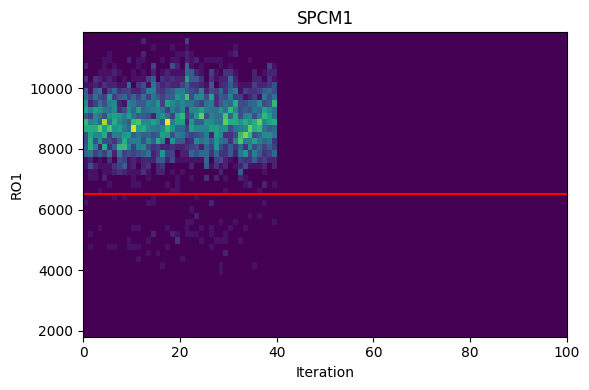

In [468]:
"""
Slicing SPCM1_RO1 into more sections to see the readout fluctuation over time in more details. 

"""

n = 100
ii = 100
SPCM1_RO1_hists = []
SPCM1_RO1_hists.append(
            [np.histogram(SPCM1_RO1[i*n:(i+1)*n]/t_SPCM_first_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(ii)])

hist_data = np.array(SPCM1_RO1_hists[0]).T  # shape: [bins, ii]

plt.figure(figsize=(6, 4))
plt.imshow(hist_data, origin='lower', extent=[0, ii, histMin, histMax], aspect='auto')

# Add horizontal line at the cutoff
plt.axhline(cutoff1 / t_SPCM_first_shot, color='red')

# Axis labels and title
plt.xlabel("Iteration")
plt.ylabel("RO1")
plt.title("SPCM1")

plt.tight_layout()
plt.show()

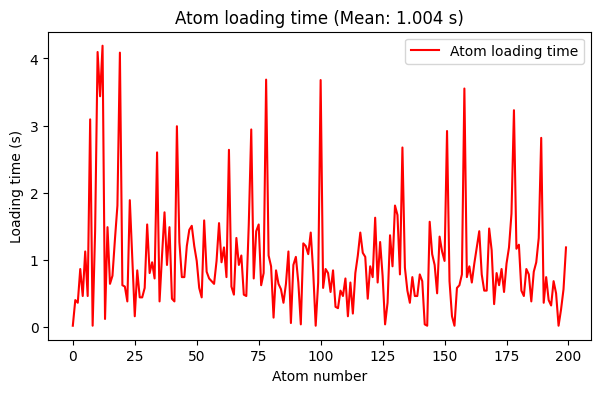

In [818]:
#### Plot the combined Atom_loading_time values
## We can slice the array to separate iterations later, if we want.
combined_atom_loading_times = list(itertools.chain(*all_atom_loading_times))
mean_loading_time = np.mean(combined_atom_loading_times[0:200])
plt.figure(figsize=(7, 4))
plt.plot(combined_atom_loading_times[0:200], 'r-', label='Atom loading time')
plt.xlabel("Atom number")
plt.ylabel("Loading time (s)")
plt.title(f"Atom loading time (Mean: {mean_loading_time:.3f} s)") 
# plt.title(f"Combined Atom Loading Time for All Files")
plt.legend(loc='best')
plt.show()

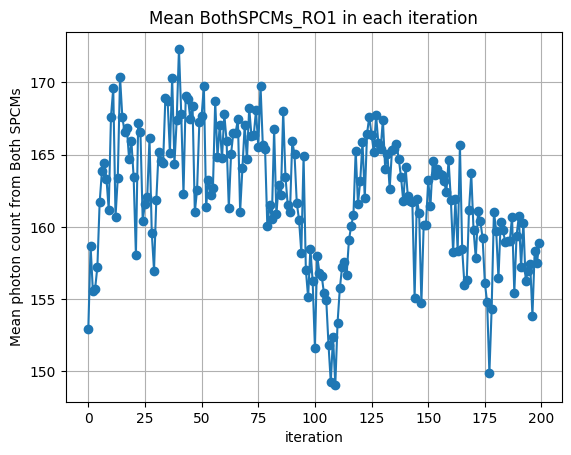

In [448]:
subarrays = np.split(BothSPCMs_RO1, iteration+1)

# Compute mean of each subarray
means = [sub.mean() for sub in subarrays]

# Plot
plt.plot(means, marker='o')
plt.title("Mean BothSPCMs_RO1 in each iteration")
plt.xlabel("iteration")
plt.ylabel("Mean photon count from Both SPCMs")
plt.grid(True)
plt.show()

## Detailed atom loading analysis - iteration averaged

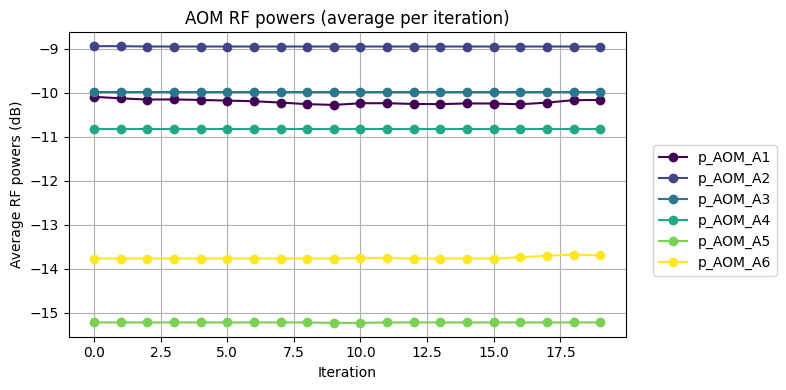

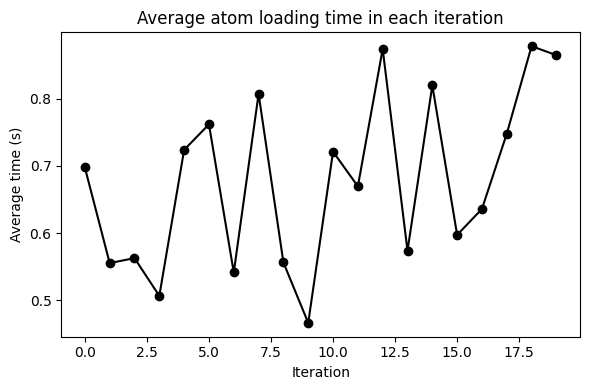

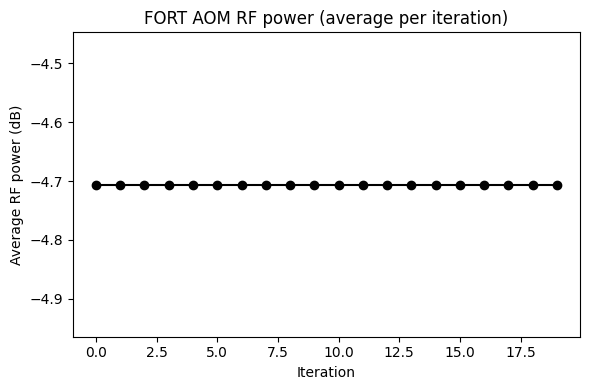

In [595]:
"""
Calculating and plotting the iteration averaged RF powers to the AOMs, along with the atom loading time. This requires n_feedback_per_iteration 
and n_atom_loaded_per_iteration datasets which are generated in some experiments.

The goal is to see if there is any correlation between bad atom loading (averaged over an iteration) and RF values (averaged over an iteration). 
This would indicate a Sampler issue, for example.

n_feedback_per_iteration[1:] = [2,2,3,2,5,...], with len()=iteration, shows the number of times the feedback ran in each iteration. Therefore, it is used to 
splice the RF power arrays, like p_AOM_A1_history, into subarrays for each iteration (first subarray for the first iteration, etc.).
"""

### Initialize list of suffixes and colors
channel_suffixes = range(1, 7)
colors = plt.cm.viridis(np.linspace(0, 1, len(channel_suffixes)))

plt.figure(figsize=(8, 4))

##### Loop over each channel to splice p_AOM_Ai_history arrays and average
for i, suffix in enumerate(channel_suffixes):
    var_name = f'p_AOM_A{suffix}_history'
    history = globals()[var_name][1:]  # skip the first element
    n_feedback = n_feedback_per_iteration[1:].astype(int)
    
    ### Compute per-iteration averages
    iteration_averages = []
    start = 0
    for count in n_feedback:
        subset = history[start:start+count]
        avg = np.mean(subset)
        iteration_averages.append(avg)
        start += count
    iteration_averages = np.array(iteration_averages)

    plt.plot(iteration_averages, marker='o', linestyle='-',
             color=colors[i], label=f'p_AOM_A{i+1}')

plt.title('AOM RF powers (average per iteration)')
plt.xlabel('Iteration')
plt.ylabel('Average RF powers (dB)')
plt.legend(loc=(1.05, 0.2))
plt.grid(True)
plt.tight_layout()
plt.show()


##### Splice Atom_loading_time array and average
Atom_loading_time_iteration_ave = []
start = 0
for count in n_atom_loaded_per_iteration[1:].astype(int):
    subset = Atom_loading_time[1:][start:start+count]
    avg = np.mean(subset)
    Atom_loading_time_iteration_ave.append(avg)
    start += count

Atom_loading_time_iteration_ave = np.array(Atom_loading_time_iteration_ave)

plt.figure(figsize=(6, 4))
plt.plot(Atom_loading_time_iteration_ave, marker='o', linestyle='-', color='black')
plt.title('Average atom loading time in each iteration')
plt.xlabel('Iteration')
plt.ylabel('Average time (s)')
plt.tight_layout()
plt.show()


###### Splice p_FORT_loading_history array and average
p_FORT_loading_history_iteration_ave = []
start = 0
for count in n_feedback_per_iteration[1:].astype(int):
    subset = p_FORT_loading_history[1:][start:start+count]
    avg = np.mean(subset)
    p_FORT_loading_history_iteration_ave.append(avg)
    start += count

p_FORT_loading_history_iteration_ave = np.array(p_FORT_loading_history_iteration_ave)

plt.figure(figsize=(6, 4))
plt.plot(p_FORT_loading_history_iteration_ave, marker='o', linestyle='-', color='black')
plt.title('FORT AOM RF power (average per iteration)')
plt.xlabel('Iteration')
plt.ylabel('Average RF power (dB)')
plt.tight_layout()
plt.show()



### Sampler test with only one channel saved (until 2026-02-16)

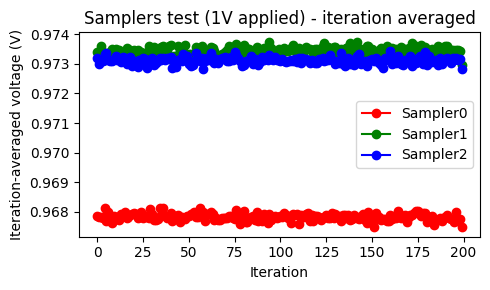

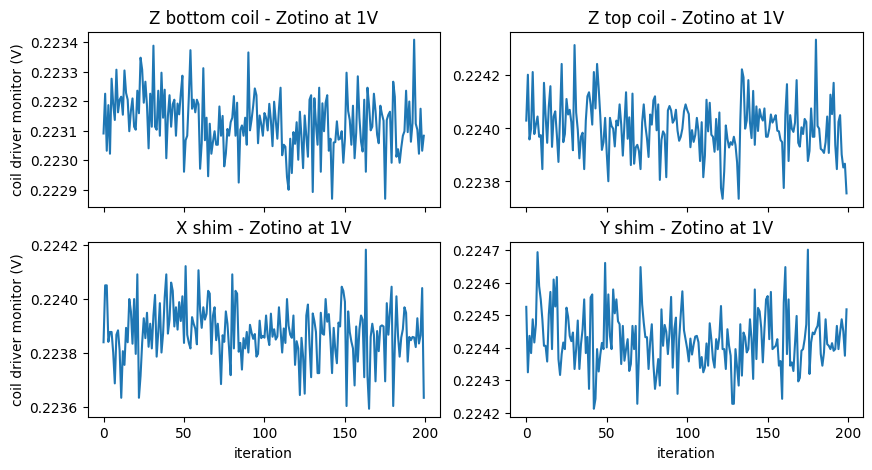

In [450]:
"""
Splice Sampler_test array and calculate average for each iteration.
Note that len(Sampler_test) is the number of times an atom is loaded. So, we need n_atom_loaded_per_iteration to find the average of the sampler in each iteration.

"""
Sampler0_iteration_ave = []
Sampler1_iteration_ave = []
Sampler2_iteration_ave = []
start = 0
for count in n_atom_loaded_per_iteration[1:].astype(int):
    subset0 = Sampler0_test[1:][start:start+count]
    avg0 = np.mean(subset0)
    Sampler0_iteration_ave.append(avg0)

    subset1 = Sampler1_test[1:][start:start+count]
    avg1 = np.mean(subset1)
    Sampler1_iteration_ave.append(avg1)

    subset2 = Sampler2_test[1:][start:start+count]
    avg2 = np.mean(subset2)
    Sampler2_iteration_ave.append(avg2)
    
    start += count

plt.figure(figsize=(5, 3))
plt.plot(Sampler0_iteration_ave, marker='o', linestyle='-', color='red', label='Sampler0')
plt.plot(Sampler1_iteration_ave, marker='o', linestyle='-', color='green', label='Sampler1')
plt.plot(Sampler2_iteration_ave, marker='o', linestyle='-', color='blue', label='Sampler2')
plt.title('Samplers test (1V applied) - iteration averaged')
plt.xlabel('Iteration')
plt.ylabel('Iteration-averaged voltage (V)')
plt.legend()
plt.tight_layout()
plt.show()


"""
Plotting the coil drivers "monitor out" added to ARTIQ since 2025-06-23, averaged for each iteration.
The "monitor out" of all 4 coil drivers are measured once by the Sampler every time we want to load an atom.

"""

coil_driver_AZ_bottom_1V_iteration_ave = []
coil_driver_AZ_top_1V_iteration_ave = []
coil_driver_AX_1V_iteration_ave = []
coil_driver_AY_1V_iteration_ave = []

start = 0
for count in n_atom_loaded_per_iteration[1:].astype(int):
    subset_bottom = coil_driver_AZ_bottom_1V[1:][start:start+count]
    avg_bottom = np.mean(subset_bottom)
    coil_driver_AZ_bottom_1V_iteration_ave.append(avg_bottom)

    subset_top = coil_driver_AZ_top_1V[1:][start:start+count]
    avg_top = np.mean(subset_top)
    coil_driver_AZ_top_1V_iteration_ave.append(avg_top)

    subset_X = coil_driver_AX_1V[1:][start:start+count]
    avg_X = np.mean(subset_X)
    coil_driver_AX_1V_iteration_ave.append(avg_X)

    subset_Y = coil_driver_AY_1V[1:][start:start+count]
    avg_Y = np.mean(subset_Y)
    coil_driver_AY_1V_iteration_ave.append(avg_Y)
    
    start += count


fig, axs = plt.subplots(2, 2, figsize=(10, 5), sharey=False, sharex=True)

axs[0, 0].plot(coil_driver_AZ_bottom_1V_iteration_ave)
axs[0, 0].set_ylabel("coil driver monitor (V)")
axs[0, 0].set_title("Z bottom coil - Zotino at 1V")

axs[0, 1].plot(coil_driver_AZ_top_1V_iteration_ave)
axs[0, 1].set_title("Z top coil - Zotino at 1V")


axs[1, 0].plot(coil_driver_AX_1V_iteration_ave)
axs[1, 0].set_xlabel("iteration")
axs[1, 0].set_ylabel("coil driver monitor (V)")
axs[1, 0].set_title("X shim - Zotino at 1V")

axs[1, 1].plot(coil_driver_AY_1V_iteration_ave)
axs[1, 1].set_xlabel("iteration")
axs[1, 1].set_title("Y shim - Zotino at 1V");

### Sampler test with all channels saved (from 2026-02-17). Includes Zotino and coil driver test

In [ ]:
"""
Splice Sampler_test array and calculate average for each iteration.
Note that len(Sampler_test) is the number of times an atom is loaded. So, we need n_atom_loaded_per_iteration to find the average of the sampler in each iteration.

"""
Not important so not done.



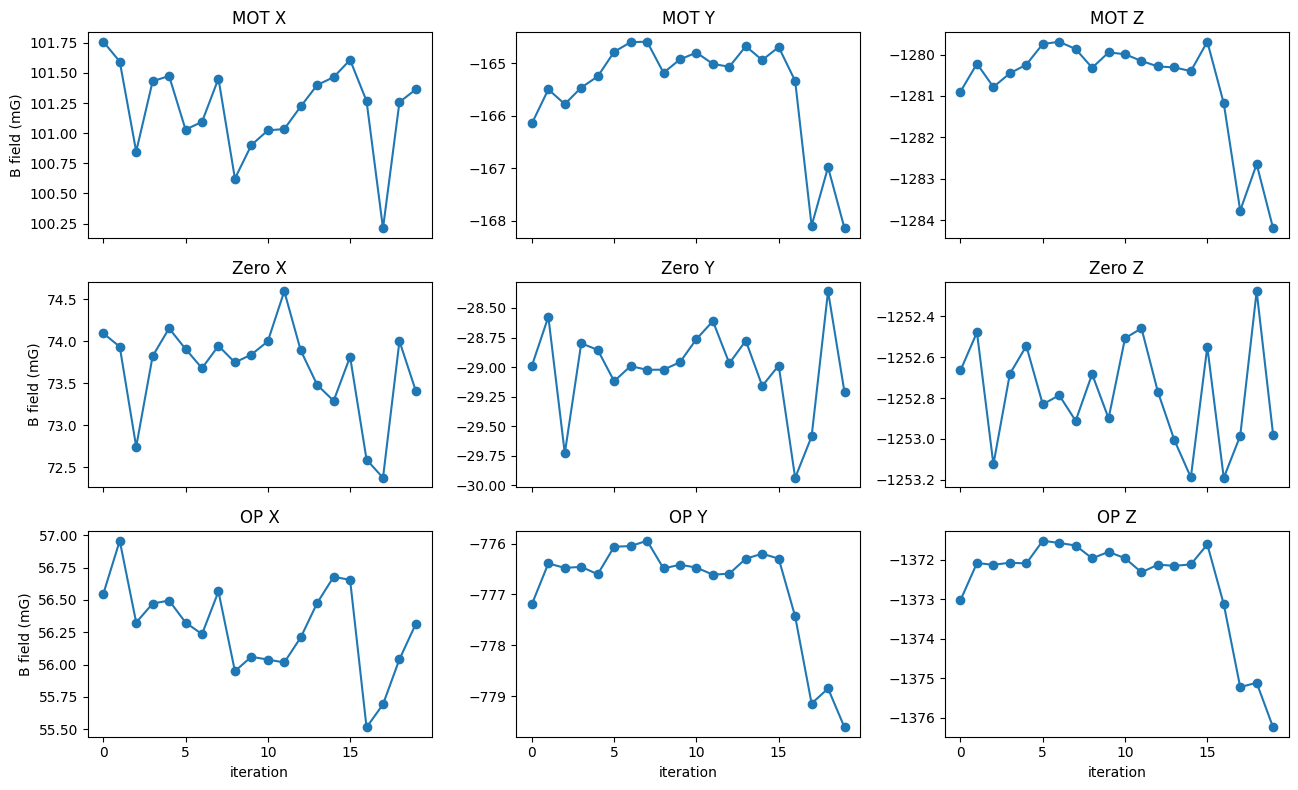

In [596]:
"""
Plotting the magnetometer averaged in each iteration.
Note that the magneometer is measured once for each atom loading.

"""

######## Splice the magnetometer data array and average over each iteration
Magnetometer_data = [Magnetometer_MOT_X[1:], Magnetometer_MOT_Y[1:], Magnetometer_MOT_Z[1:], 
                     Magnetometer_Zero_X[1:], Magnetometer_Zero_Y[1:], Magnetometer_Zero_Z[1:],
                     Magnetometer_OP_X[1:], Magnetometer_OP_Y[1:], Magnetometer_OP_Z[1:]]

Magnetometer_data_iteration_ave = [[] for _ in range(len(Magnetometer_data))]

for d in range(len(Magnetometer_data)):
    start = 0
    for count in n_atom_loaded_per_iteration[1:].astype(int):      
        subset = Magnetometer_data[d][start:start+count]
        avg = np.mean(subset)
        Magnetometer_data_iteration_ave[d].append(avg)
        start += count



fig, axs = plt.subplots(3, 3, figsize=(13, 8), sharey=False, sharex=True)
titles = [
    "MOT X", "MOT Y", "MOT Z",
    "Zero X", "Zero Y", "Zero Z",
    "OP X", "OP Y", "OP Z"
]

ylabels = ["B field (mG)"] + [""]*2 + ["B field (mG)"] + [""]*2 + ["B field (mG)"] + [""]*2
xlabels = [""] * 6 + ["iteration"] * 3  # Only bottom row gets x-axis labels

for idx, avg_data in enumerate(Magnetometer_data_iteration_ave):
    row = idx // 3
    col = idx % 3
    ax = axs[row, col]
    
    ax.plot(avg_data, marker='o')  # add markers for clarity
    ax.set_title(titles[idx])
    
    if ylabels[idx]:
        ax.set_ylabel(ylabels[idx])
    if xlabels[idx]:
        ax.set_xlabel(xlabels[idx])

plt.tight_layout()
plt.show()


## without iteration averaging

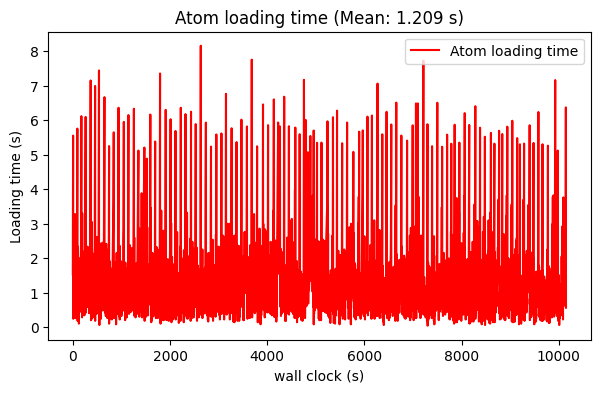

In [302]:
#### Plot the combined Atom_loading_time values vs wall clock. I want to see if bad loading times are periodic or not.
combined_atom_loading_times = list(itertools.chain(*all_atom_loading_times))
mean_loading_time = np.mean(combined_atom_loading_times)

combined_atom_loading_wall_clocks = list(itertools.chain(*all_atom_loading_wall_clocks))
combined_atom_loading_wall_clocks_in_sec = (combined_atom_loading_wall_clocks - combined_atom_loading_wall_clocks[0])*1e-9

plt.figure(figsize=(7, 4))
plt.plot(combined_atom_loading_wall_clocks_in_sec, combined_atom_loading_times, 'r-', label='Atom loading time')
plt.xlabel("wall clock (s)")
plt.ylabel("Loading time (s)")
plt.title(f"Atom loading time (Mean: {mean_loading_time:.3f} s)") 
# plt.title(f"Combined Atom Loading Time for All Files")
plt.legend(loc='best')
plt.show()

### Sampler test with only one channel saved (until 2026-02-16)

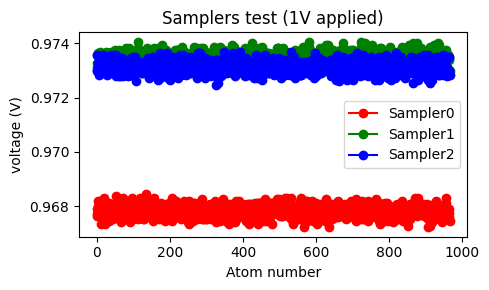

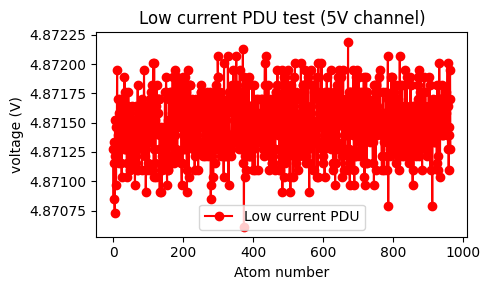

In [544]:
"""
Plot Sampler test results without iteration averaging.

"""

plt.figure(figsize=(5, 3))
plt.plot(Sampler0_test[1:], marker='o', linestyle='-', color='red', label='Sampler0')
plt.plot(Sampler1_test[1:], marker='o', linestyle='-', color='green', label='Sampler1')
plt.plot(Sampler2_test[1:], marker='o', linestyle='-', color='blue', label='Sampler2')
plt.title('Samplers test (1V applied)')
plt.xlabel('Atom number')
plt.ylabel('voltage (V)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(GRIN1_D1_monitor[1:], marker='o', linestyle='-', color='red', label='Low current PDU')
plt.title('Low current PDU test (5V channel)')
plt.xlabel('Atom number')
plt.ylabel('voltage (V)')
plt.legend()
plt.tight_layout()
plt.show()



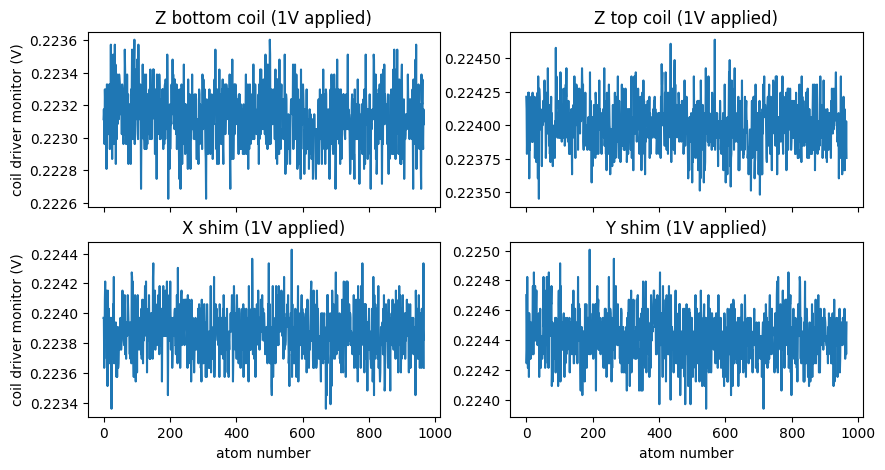

In [545]:
"""
Plotting the coil drivers "monitor out" added to ARTIQ since 2025-06-23, for every atom loading.
The "monitor out" of all 4 coil drivers are measured once by the Sampler every time we want to load an atom.

"""
fig, axs = plt.subplots(2, 2, figsize=(10, 5), sharey=False, sharex=True)

######## MOT
axs[0, 0].plot(coil_driver_AZ_bottom_1V[1:])
axs[0, 0].set_ylabel("coil driver monitor (V)")
axs[0, 0].set_title("Z bottom coil (1V applied)")

axs[0, 1].plot(coil_driver_AZ_top_1V[1:])
axs[0, 1].set_title("Z top coil (1V applied)")


axs[1, 0].plot(coil_driver_AX_1V[1:])
axs[1, 0].set_xlabel("atom number")
axs[1, 0].set_ylabel("coil driver monitor (V)")
axs[1, 0].set_title("X shim (1V applied)")

axs[1, 1].plot(coil_driver_AY_1V[1:])
axs[1, 1].set_xlabel("atom number")
axs[1, 1].set_title("Y shim (1V applied)");



### Sampler test with all channels saved (from 2026-02-17). Includes Zotino and coil driver test

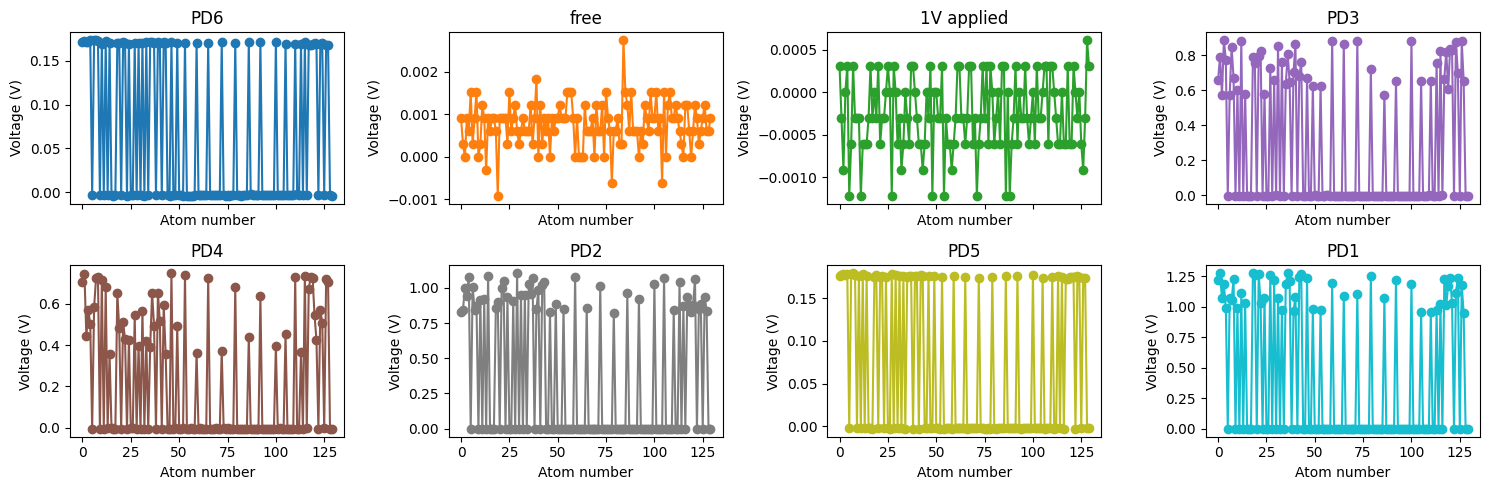

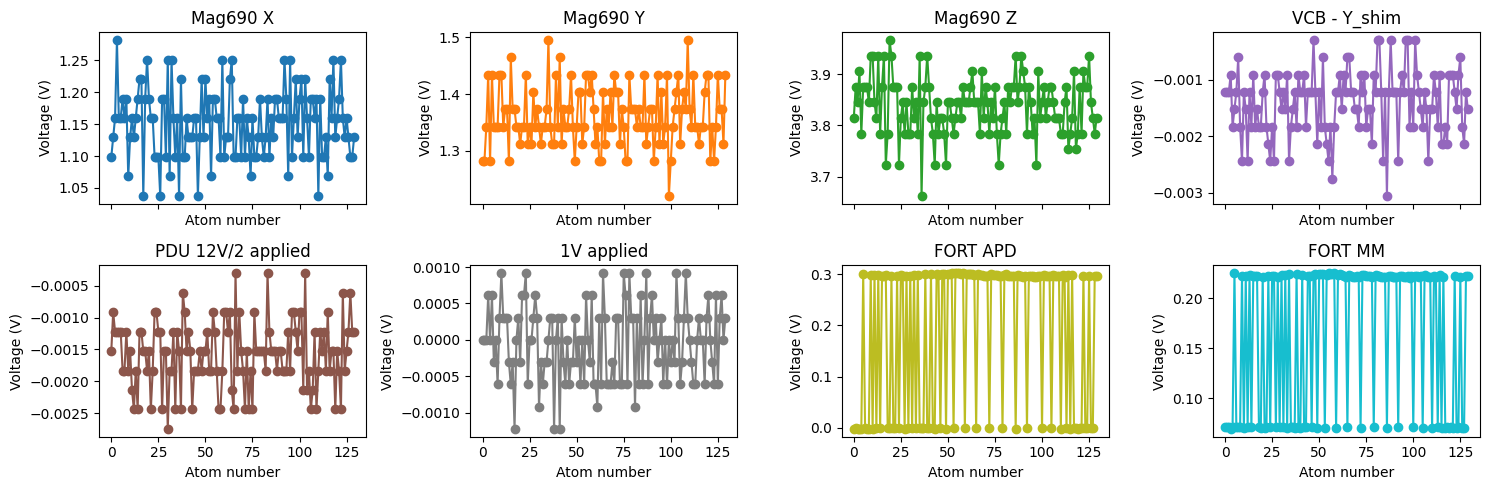

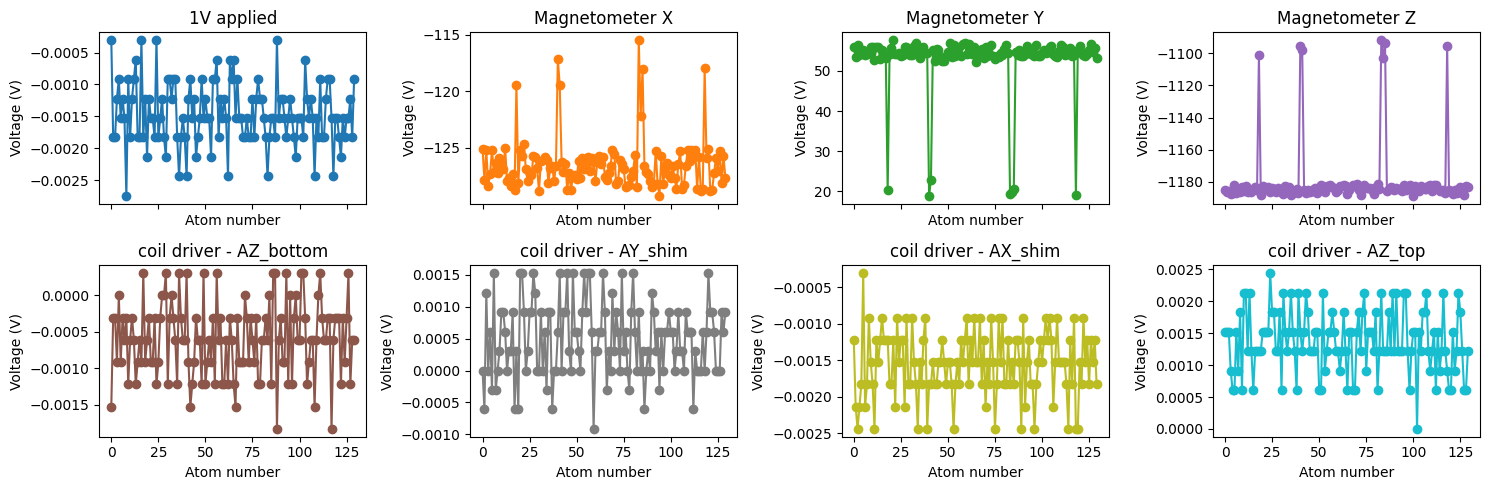

In [880]:
import matplotlib.cm as cm
colors = cm.tab10(np.linspace(0, 1, 8))

### Print a title for each Sampler
display(HTML(f"""<b style='font-size:18px;'> Sampler0"""))

Sampler0_title_list = ["PD6", "free", "1V applied", "PD3", "PD4", "PD2", "PD5", "PD1"]

fig, axs = plt.subplots(2, 4, figsize=(15, 5), sharey=False, sharex=True)

axs = axs.flatten()  # Make indexing easier

for i in range(8):
    axs[i].plot(Sampler0_test[1:, i], marker='o', linestyle='-', color=colors[i], label='Voltage')
    axs[i].set_title(Sampler0_title_list[i])
    axs[i].set_xlabel('Atom number')
    axs[i].set_ylabel('Voltage (V)')
    # axs[i].legend()

plt.tight_layout()
plt.show()


### Print a title for each Sampler
display(HTML(f"""<b style='font-size:18px;'>  Sampler1"""))

Sampler1_title_list = ["Mag690 X", "Mag690 Y", "Mag690 Z", "VCB - Y_shim", "PDU 12V/2 applied", "1V applied", "FORT APD", "FORT MM"]

fig, axs = plt.subplots(2, 4, figsize=(15, 5), sharey=False, sharex=True)

axs = axs.flatten()  # Make indexing easier

for i in range(8):
    ### for mag690 magnetometer multiply by 100 to convert 1V to 100 mG
    if i==0 or i==1 or i==2:
        x=100
    else:
        x=1
        
    axs[i].plot(Sampler1_test[1:, i]*x, marker='o', linestyle='-', color=colors[i], label='Voltage')
    axs[i].set_title(Sampler1_title_list[i])
    axs[i].set_xlabel('Atom number')
    axs[i].set_ylabel('Voltage (V)')
    # axs[i].legend()

plt.tight_layout()
plt.show()


### Print a title for each Sampler
display(HTML(f"""<b style='font-size:18px;'>  Sampler2"""))

Sampler2_title_list = ["1V applied", "Magnetometer X", "Magnetometer Y", "Magnetometer Z", "coil driver - AZ_bottom", "coil driver - AY_shim", "coil driver - AX_shim", "coil driver - AZ_top"]

fig, axs = plt.subplots(2, 4, figsize=(15, 5), sharey=False, sharex=True)

axs = axs.flatten()  # Make indexing easier

for i in range(8):
    ### for magnetometer multiply by 350 to convert 1V to 350mG
    if i==1 or i==2 or i==3:
        x=350
    else:
        x=1
        
    axs[i].plot(Sampler2_test[1:, i]*x, marker='o', linestyle='-', color=colors[i], label='Voltage')
    axs[i].set_title(Sampler2_title_list[i])
    axs[i].set_xlabel('Atom number')
    axs[i].set_ylabel('Voltage (V)')
    # axs[i].legend()

plt.tight_layout()
plt.show()


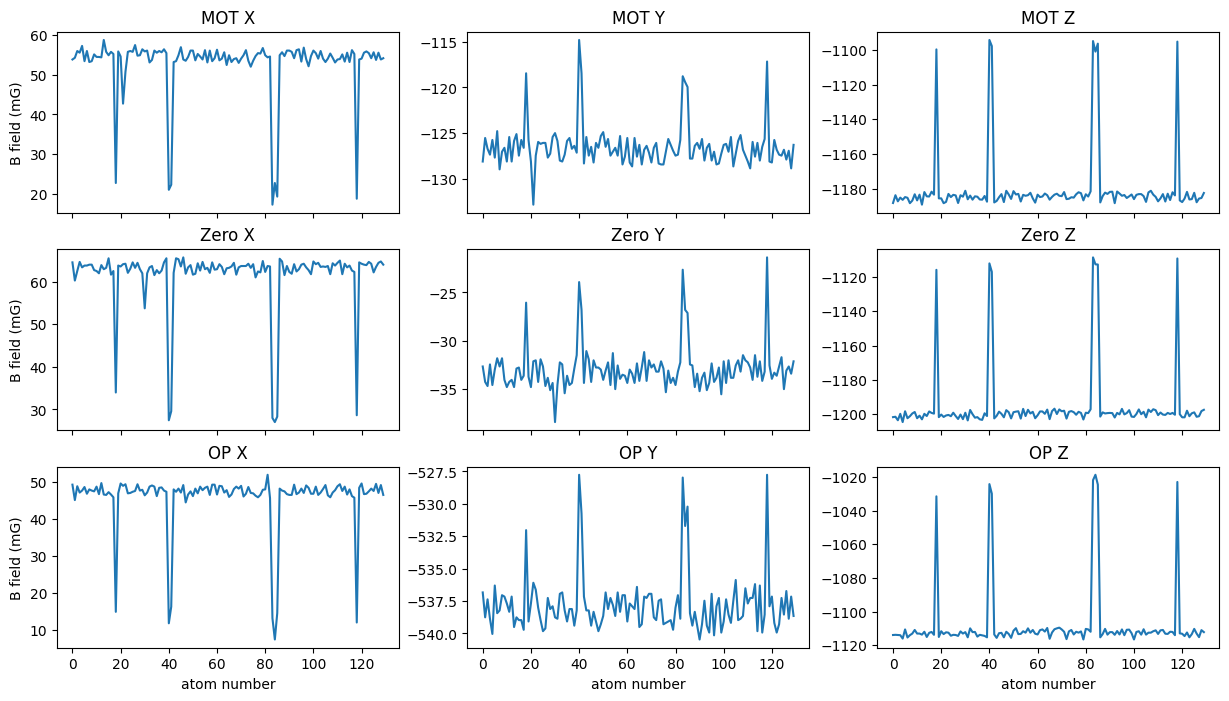

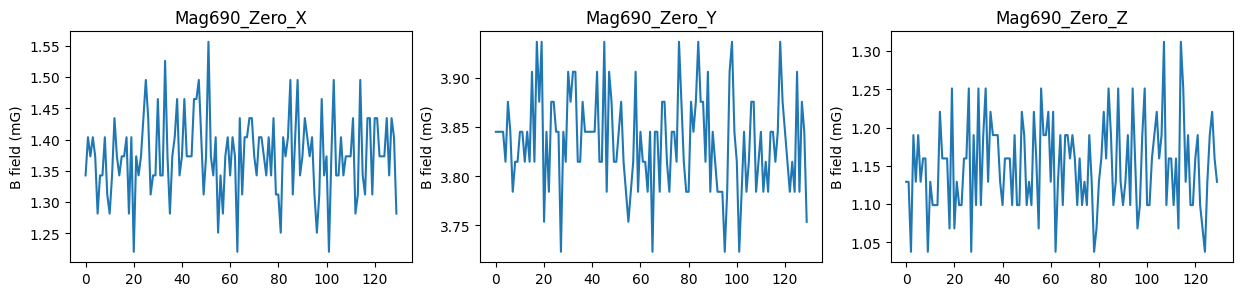

In [881]:
"""
Plotting the magnetometer added to ARTIQ since 2025-04-19.
For all atom loading events. Note that the magneometer is measured in every "measurement".

"""
fig, axs = plt.subplots(3, 3, figsize=(15, 8), sharey=False, sharex=True)

######## MOT
axs[0, 0].plot(Magnetometer_MOT_X[1:])
axs[0, 0].set_ylabel("B field (mG)")
axs[0, 0].set_title("MOT X")

axs[0, 1].plot(Magnetometer_MOT_Y[1:])
axs[0, 1].set_title("MOT Y")

axs[0, 2].plot(Magnetometer_MOT_Z[1:])
axs[0, 2].set_title("MOT Z");


######## Zero
axs[1, 0].plot(Magnetometer_Zero_X[1:])
axs[1, 0].set_ylabel("B field (mG)")
axs[1, 0].set_title("Zero X")

axs[1, 1].plot(Magnetometer_Zero_Y[1:])
axs[1, 1].set_title("Zero Y")

axs[1, 2].plot(Magnetometer_Zero_Z[1:])
axs[1, 2].set_title("Zero Z");


######## OP
axs[2, 0].plot(Magnetometer_OP_X[1:])
axs[2, 0].set_xlabel("atom number")
axs[2, 0].set_ylabel("B field (mG)")
axs[2, 0].set_title("OP X")

axs[2, 1].plot(Magnetometer_OP_Y[1:])
axs[2, 1].set_xlabel("atom number")
axs[2, 1].set_title("OP Y")

axs[2, 2].plot(Magnetometer_OP_Z[1:])
axs[2, 2].set_xlabel("atom number")
axs[2, 2].set_title("OP Z");


#### Added Mag690 to compare with our magnetometer. To be deleted soon
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharey=False, sharex=True)

######## Mag690 Zero
### Mag690 x is along x of our magnetometer
### Mag690 y is along z of our magnetometer
### Mag690 z is along y of our magnetometer

axs[0].plot(Magnetometer_Mag690_Zero_X[1:])
axs[0].set_ylabel("B field (mG)")
axs[0].set_title("Mag690_Zero_X")

axs[1].plot(Magnetometer_Mag690_Zero_Z[1:])
axs[1].set_ylabel("B field (mG)")
axs[1].set_title("Mag690_Zero_Y")

axs[2].plot(Magnetometer_Mag690_Zero_Y[1:])
axs[2].set_ylabel("B field (mG)")
axs[2].set_title("Mag690_Zero_Z");




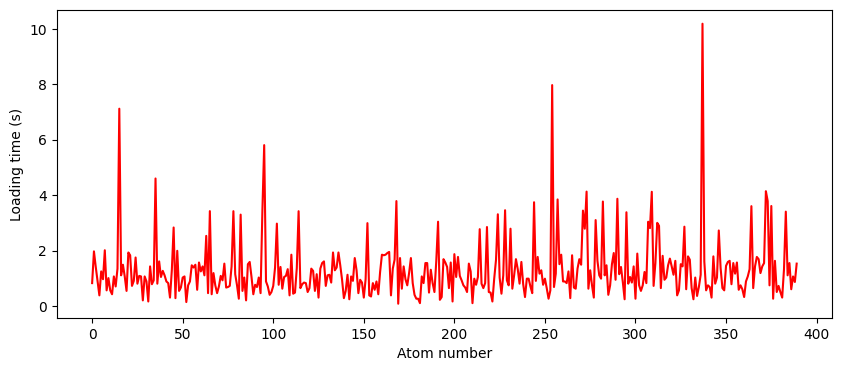

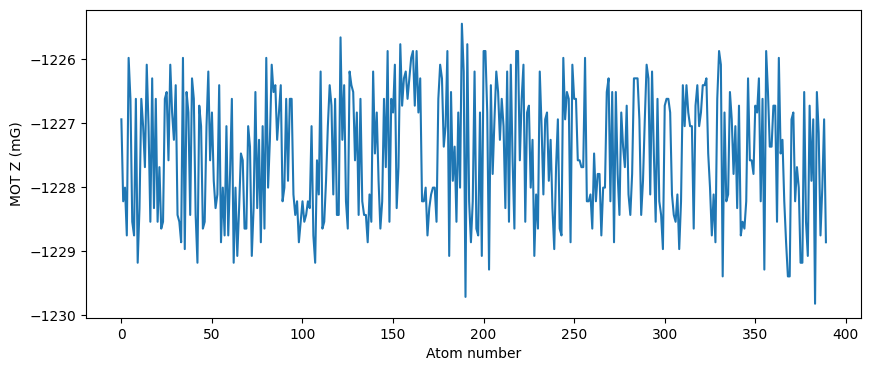

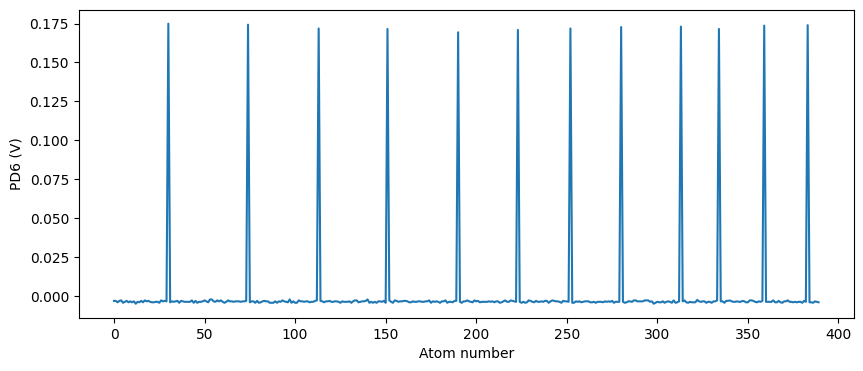

In [854]:
#### Plot the combined Atom_loading_time values
## We can slice the array to separate iterations later, if we want.
combined_atom_loading_times = list(itertools.chain(*all_atom_loading_times))

start_range = 10
end_range = 400

plt.figure(figsize=(10, 4))
plt.plot(combined_atom_loading_times[start_range:end_range], 'r-', label='Atom loading time')
plt.xlabel("Atom number")
plt.ylabel("Loading time (s)")
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(Magnetometer_MOT_Z[start_range:end_range])
plt.xlabel("Atom number")
plt.ylabel("MOT Z (mG)")
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(Sampler0_test[1:, 0][start_range:end_range])
plt.xlabel("Atom number")
plt.ylabel("PD6 (V)")
plt.show()


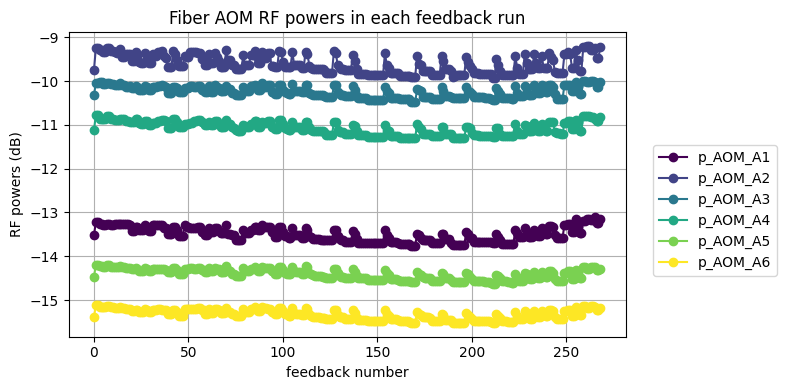

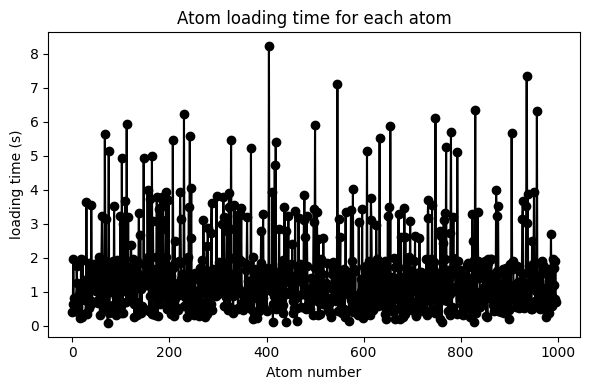

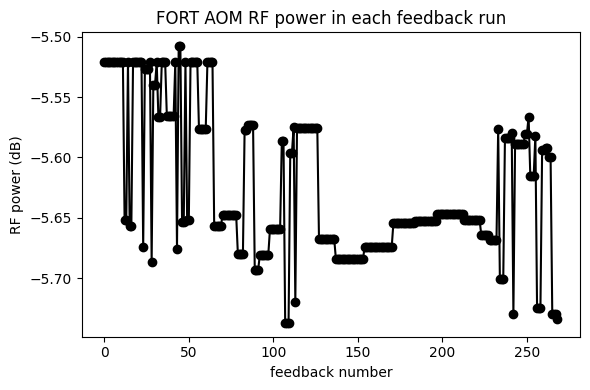

In [877]:
"""
Plotting the RF powers to the AOMs, along with the atom loading time. 

"""

### Initialize list of suffixes and colors
channel_suffixes = range(1, 7)
colors = plt.cm.viridis(np.linspace(0, 1, len(channel_suffixes)))

plt.figure(figsize=(8, 4))

##### Loop over each channel to splice p_AOM_Ai_history arrays
for i, suffix in enumerate(channel_suffixes):
    var_name = f'p_AOM_A{suffix}_history'
    history = globals()[var_name][1:]  # skip the first element
    
    plt.plot(history, marker='o', linestyle='-',
             color=colors[i], label=f'p_AOM_A{i+1}')

plt.title('Fiber AOM RF powers in each feedback run')
plt.xlabel('feedback number')
plt.ylabel('RF powers (dB)')
plt.legend(loc=(1.05, 0.2))
plt.grid(True)
plt.tight_layout()
plt.show()


##### Splice Atom_loading_time array and average
plt.figure(figsize=(6, 4))
plt.plot(Atom_loading_time[1:], marker='o', linestyle='-', color='black')
plt.title('Atom loading time for each atom')
plt.xlabel('Atom number')
plt.ylabel('loading time (s)')
plt.tight_layout()
plt.show()


###### Splice p_FORT_loading_history array and average
plt.figure(figsize=(6, 4))
plt.plot(p_FORT_loading_history[1:], marker='o', linestyle='-', color='black')
plt.title('FORT AOM RF power in each feedback run')
plt.xlabel('feedback number')
plt.ylabel('RF power (dB)')
plt.tight_layout()
plt.show()



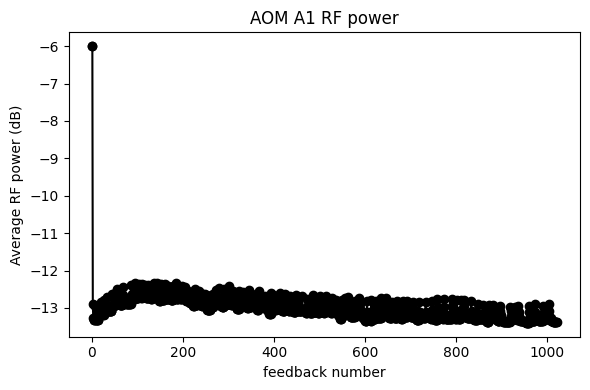

In [791]:
"""
RF plot of just one AOM
"""
plt.figure(figsize=(6, 4))
plt.plot(p_AOM_A1_history, marker='o', linestyle='-', color='black')
plt.title('AOM A1 RF power')
plt.xlabel('feedback number')
plt.ylabel('Average RF power (dB)')
plt.tight_layout()
plt.show()

# Atom loading analysis
Valid for experiments from 2025-04-30 until 202506-23

In the experiment, I measure and save Atom_loading_time only when I load an atom, not in each measurement or each iteration. However, I run measure_Magnetometer in end_measurement which runs n_measurements times in each iteration. Thus I do some analysis to find the averages for each iteration.


In [1]:
date_filters = ["2025-06-23"]

from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import csv
import numpy as np
import os,sys
import PIL # for reading tif images
import h5py
import datetime as dt
import time
from scipy.optimize import curve_fit
from skimage.filters import threshold_otsu
from IPython.display import display, HTML ## for large prints
import math
import itertools

sys.path.append("..\\")
from h5_data_utilities import * # helper functions for dealing with h5 files

def average_over_measurement(measurements, history):
    iteration = len(history) // measurements
    mean_by_iteration = [np.mean(history[j * measurements:(j + 1) * measurements]) for j in range(iteration)]
    return mean_by_iteration


fnames = get_files_by_criteria(date_filters, # only find files from these date directories
                               name_filters=["GeneralVariableScan"], # only find files containing all these strings
                               condition=lambda filename: True, # use this to filter by experiment parameters, like this: lambda filename: np.bool_(h5py.File(filename)['datasets']['set_current_coil_volts_at_finish'])
                               start_dir=results,
                               include_path=True, # if False, only return the name of the file, not the full path
                               print_filenames=True
)


only_show_i_greater_than = -1

print(f"found {len(fnames)} files")
for i,f in enumerate(fnames):
    if i > only_show_i_greater_than:
        try:
            ds = h5py.File(os.path.join(results, f))['datasets']
            scan_str = str_from_h5(ds['scan_variable1_name'])
            if str_from_h5(ds['scan_variable2_name']) != '':
                scan_str += ", " +str_from_h5(ds['scan_variable2_name'])
            print(f"file {i} ({f}) scanned over "+scan_str)
        except:

            print(f"oops... something wrong with {f}")

skipping C:\Networking Experiment\artiq codes\artiq-master\results\2025-06-23\15\000027591-GeneralVariableScan_microwave_Rabi_2_scan_over_f_microwaves_dds.h5, which is corrupt
skipping C:\Networking Experiment\artiq codes\artiq-master\results\2025-06-23\15\000027592-GeneralVariableScan_microwave_Rabi_2_scan_over_f_microwaves_dds.h5, which is corrupt
found 19 files
file 0 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-06-23\05\000027566-GeneralVariableScan.h5) scanned over f_microwaves_dds
file 1 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-06-23\05\000027566-GeneralVariableScan_microwave_Rabi_2_scan_over_f_microwaves_dds.h5) scanned over f_microwaves_dds
file 2 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-06-23\07\000027567-GeneralVariableScan.h5) scanned over f_microwaves_dds
file 3 (C:\Networking Experiment\artiq codes\artiq-master\results\2025-06-23\07\000027567-GeneralVariableScan_microwave_Rabi_2_scan_over_f_microwaves_dds.h5)

## Combine files - Fitting resonance dip

experiment: microwave_Rabi_2_experiment
override: {'dummy_variable':4,'p_excitation':-40.0,'t_microwave_pulse':24*us,'f_microwaves_dds':(341.714+0.03)*MHz}
# of iterations:  10
center=338201468.9255, sigma=11202.2697, depth=1.0000


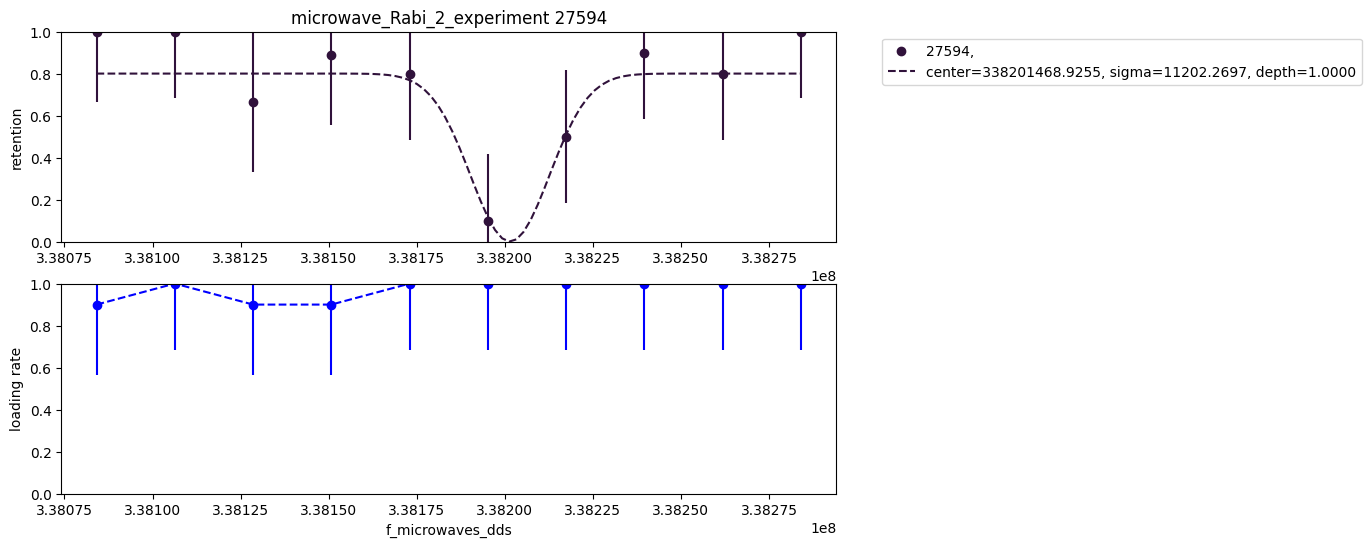

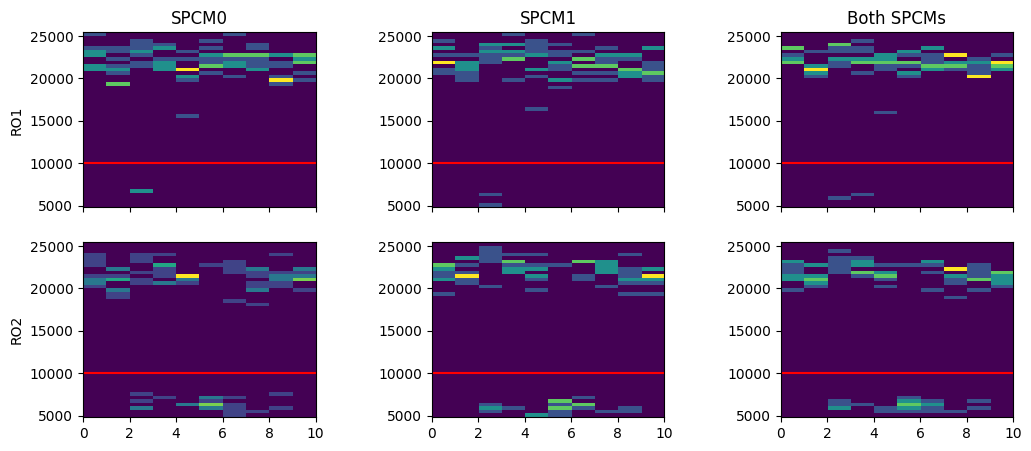

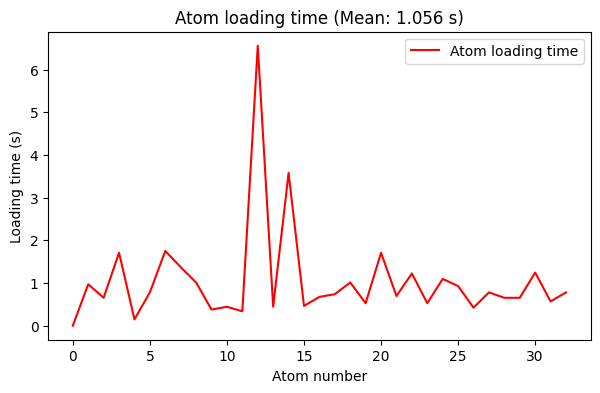

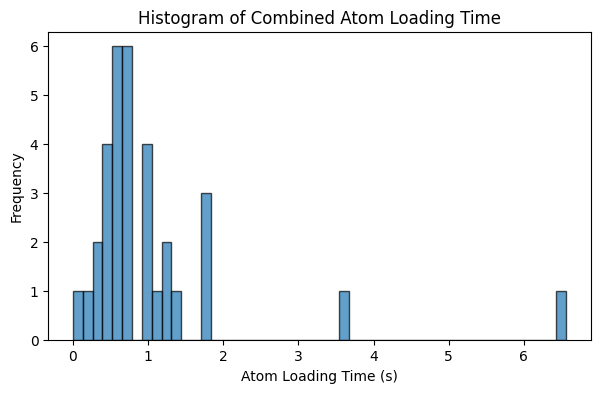

In [4]:
"""
With fitting the resonance for microwave scans

"""
### the file(s) to analyze:
file_indices = {
    16:'',
    # 46:'',
    # 48:''
} 

# file_indices = {i: '' for i in range(19, 33, 2)}

compare = True # compare multiple files in the same retention and loading plots
otsu_threshold = False # compute threshold using Otsu method instead doing it by eye. only work when require atom loading = False
showhist = True
showloading = True
custom_xlabel = True
merge_data = False # if True, the datasets will be combined, and if fit=True, the new merged data will be fit. don't try this in 2D
fit = True

showhist_counts = False 

# for plotting
legend_vars =[]   #legend_vars = ['AY_volts_OP', 'f_microwaves_dds'] # will be included in the plot legend
xform_and_label = {}
loc='best'
ret_cmap = mpl.colormaps['turbo']
ldng_cmap = mpl.colormaps['winter']

if compare:
    if showloading:
        fig_ret,axes = plt.subplots(nrows=2, sharex=False, figsize=(10, 6))
        ax_ret, ax_ldng = axes
    else:
        fig_ret,ax_ret = plt.subplots()


SPCM0_RO1_hists = []
SPCM0_RO2_hists = []
SPCM1_RO1_hists = []
SPCM1_RO2_hists = []
BothSPCMs_RO1_hists = []
BothSPCMs_RO2_hists = []
mean1_by_iteration = []
mean2_by_iteration = []

merged_retention = np.array([])
merged_scan_sequence1 = np.array([])
merged_errs = np.array([])
rid_str = ''

all_atom_loading_times = []

for idx,f_item in enumerate(file_indices.items()):
    f_idx,f_comment = f_item   # idx - f_item = {f_idx: f_comment}
    f = h5py.File(os.path.join(results, fnames[f_idx]))
    rid = f['rid'][()]
    h5_archive_and_datasets_to_locals(f, parent_locals=locals(), quiet=True)
    print("experiment:",experiment_function)
    print("override:",override_ExperimentVariables)

    iterations = len(scan_sequence1) #int(len(SPCM0_RO1)/n_measurements)
    print("# of iterations: ", iterations)

    all_atom_loading_times.append(Atom_loading_time)
    
    if otsu_threshold:
        thresh = threshold_otsu(BothSPCMs_RO1)
        print("threshold_otsu: ", thresh)
    else:
        cutoff1 = cutoff2 = single_atom_threshold * t_SPCM_first_shot

    
    ### for plotting 
    ### xsteps_xform is a function that can transform scan_sequence1 for plotting. Here it is equal to identity, i.e. no change in scan_sequence1.
    if scan_variable1_name in xform_and_label and custom_xlabel:
        xsteps_xform, xlabel = (xform_and_label[scan_variable1_name]['xsteps_xform'], xform_and_label[scan_variable1_name]['xlabel'])
    else:
        xsteps_xform, xlabel = (lambda x: x, scan_variable1_name)
        

    legend_string = ''
    for a in legend_vars:
        legend_string += f'{a}={locals()[a]}, '
    legend_string = legend_string[:-2]
    f_comment += legend_string

    
    ### get_loading_and_retention
    ### These array have length = iterations
    retention_array, loading_rate_array, n_atoms_loaded_array = get_loading_and_retention(BothSPCMs_RO1, BothSPCMs_RO2, n_measurements, iterations, cutoff1, otsu=otsu_threshold)


    ### Necessary to analyze data with 2 scan_sequences
    ### reshaping each array into a 2D array with shape = shape, with order = 'F' (Fortran-style) to sort column by column
    
    ncols = len(scan_sequence2)
    nrows = len(scan_sequence1)
    shape = (len(scan_sequence2),len(scan_sequence1))
    loading_rate_raveled = np.reshape(loading_rate_array,shape,order='F') # rows have constant variable2
    n_atoms_loaded_raveled = np.reshape(n_atoms_loaded_array,shape,order='F') # rows have constant variable2
    retention_raveled = np.reshape(retention_array,shape,order='F') # rows have constant variable2

    
    ### show historam of first_shot and second_shot
    histMin = np.min([SPCM0_RO1, SPCM0_RO2, SPCM1_RO1, SPCM1_RO2])/t_SPCM_first_shot ## boundary for the histogram plots
    histMax = np.max([SPCM0_RO1, SPCM0_RO2, SPCM1_RO1, SPCM1_RO2])/t_SPCM_first_shot
    if showhist:
        SPCM0_RO1_hists.append(
            [np.histogram(SPCM0_RO1[i*n_measurements:(i+1)*n_measurements]/t_SPCM_first_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])

        SPCM0_RO2_hists.append(
            [np.histogram(SPCM0_RO2[i*n_measurements:(i+1)*n_measurements]/t_SPCM_second_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])

        SPCM1_RO1_hists.append(
            [np.histogram(SPCM1_RO1[i*n_measurements:(i+1)*n_measurements]/t_SPCM_first_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])

        SPCM1_RO2_hists.append(
            [np.histogram(SPCM1_RO2[i*n_measurements:(i+1)*n_measurements]/t_SPCM_second_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])
        
        BothSPCMs_RO1_hists.append(
            [np.histogram(BothSPCMs_RO1[i*n_measurements:(i+1)*n_measurements]/t_SPCM_first_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])

        BothSPCMs_RO2_hists.append(
            [np.histogram(BothSPCMs_RO2[i*n_measurements:(i+1)*n_measurements]/t_SPCM_second_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(iterations)])

    
    ### plot a retention curve vs variable 1 for each variable 2 value
    for i, retention, loading, n_loaded, var2 in zip(range(len(scan_sequence2)), retention_raveled, loading_rate_raveled, n_atoms_loaded_raveled, scan_sequence2):
        
        errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
        if not compare:
            if showloading:
                    fig_ret,axes = plt.subplots(nrows=2, sharex=False)
                    ax_ret, ax_ldng = axes
            else:
                fig_ret,ax_ret = plt.subplots()
                
        if not merge_data:
            ax_ret.scatter(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], label=str(rid)+', '+f_comment, color=ret_cmap(idx/len(file_indices)))
            ax_ret.errorbar(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0], errs[loading > 0], ls='none',color=ret_cmap(idx/len(file_indices)))
            ax_ret.set_ylim((0,1))

            ### for fitting
            ### Auto-detect rough center from minimum retention
            fit_dict = {}
            min_idx = np.argmin(retention_array)
            initial_center = scan_sequence1[min_idx]
            p0 = [initial_center, 10e3, 0.9] # [center, width, depth]
            
            ### using a  Gaussian function for now:
            fit_dict = {
                scan_variable1_name: {
                    'model': lambda x, center, sigma, depth: 0.80*(1 - depth * np.exp(-((x - center)**2/(2*sigma**2)))),
                    'p0': p0,
                    'bounds': ([min(scan_sequence1), 0, 0], [max(scan_sequence1), np.inf, 1]),
                    'params': ['center', 'sigma', 'depth']
                }
            }

            if not ncols > 1 and fit and scan_variable1_name in fit_dict:
                popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
                fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
                print(fit_str)
                hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
                hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
                ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color=ret_cmap(idx/len(file_indices)),label=fit_str)
            else:
                ax_ret.plot(xsteps_xform(scan_sequence1)[loading > 0], retention[loading > 0],linestyle='--',color=ret_cmap(idx/len(file_indices)))
    
            if not showloading:
                ax_ret.set_xlabel(xlabel)
            ax_ret.set_ylabel("retention")
            #ax_ret.legend(loc=loc)
            ax_ret.legend(bbox_to_anchor=(1.05, 1), loc='upper left')      # This will show the legend outside the plot
            
        else:
            merged_retention = np.concatenate((merged_retention,retention[loading > 0]))
            merged_scan_sequence1 = np.concatenate((merged_scan_sequence1, scan_sequence1[loading > 0]))
            merged_errs = np.concatenate((merged_errs, errs[loading > 0]))
            rid_str += str(rid) + ', '
    
        if showloading:
            ax_ldng.plot(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], linestyle='--',color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.scatter(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], label=rid, color=ldng_cmap(idx/len(file_indices)))
            errs = np.array([1/np.sqrt(n) if n > 0 else np.inf for n in n_loaded])
            ax_ldng.errorbar(xsteps_xform(scan_sequence1)[loading > 0], loading[loading > 0], errs[loading > 0], ls='none', color=ldng_cmap(idx/len(file_indices)))
            ax_ldng.set_ylim((0,1))
            ax_ldng.set_xlabel(xlabel)
            ax_ldng.set_ylabel("loading rate")


if merge_data:
    retention = merged_retention
    scan_sequence1 = merged_scan_sequence1
    errs = merged_errs

    ax_ret.scatter(xsteps_xform(scan_sequence1), retention, color='plum')
    ax_ret.errorbar(xsteps_xform(scan_sequence1), retention, errs, ls='none',color='plum')
    ax_ret.set_ylim((0,1))
    
    if not ncols > 1 and fit and scan_variable1_name in fit_dict:        
        popt, _ = curve_fit(f=fit_dict[scan_variable1_name]['model'], xdata=scan_sequence1, ydata=retention, p0=fit_dict[scan_variable1_name]['p0'], bounds=fit_dict[scan_variable1_name]['bounds'])
        hi_res_x = np.linspace(scan_sequence1[0], scan_sequence1[-1], 10*len(scan_sequence1))
        hi_res_x_xform = np.linspace(xsteps_xform(scan_sequence1)[0], xsteps_xform(scan_sequence1)[-1], 10*len(scan_sequence1))
        fit_str = "".join([f'{p}={v:.4f}, ' for p,v in zip(fit_dict[scan_variable1_name]['params'], popt)])[:-2]
        print(fit_str)
        ax_ret.plot(hi_res_x_xform, fit_dict[scan_variable1_name]['model'](hi_res_x, *popt),linestyle='--',color='violet', label=fit_str)
        ax_ret.legend()
    else:
        ax_ret.plot(xsteps_xform(scan_sequence1), retention,linestyle='--',color='violet')


if not compare or len(file_indices)==1:
    ax_ret.set_title(experiment_function+' '+str(rid))
elif merge_data:
    ax_ret.set_title(experiment_function+' '+ rid_str[:-2])
else:
    ax_ret.set_title(experiment_function)

if showhist:
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 5), sharex=True)  # 2 rows, 3 columns
    ax, ax2, ax3, ax4, ax5, ax6 = axes.ravel()  # Flatten the 2D axes array for easier unpacking

    ### Plot for SPCM0 RO1 in the 1st row, 1st column
    cax = ax.imshow(np.array(SPCM0_RO1_hists[0]).transpose(), origin='lower', extent=[0, iterations, histMin, histMax])
    ax.set_ylabel("RO1")
    ax.axhline(cutoff1 / t_SPCM_first_shot, color='red')
    ax.set_aspect('auto')
    ax.set_title("SPCM0")

    ### Plot for SPCM1 RO1 in the 1st row, 2nd column
    cax2 = ax2.imshow(np.array(SPCM1_RO1_hists[0]).transpose(), origin='lower', extent=[0, iterations, histMin, histMax])
    ax2.axhline(cutoff1 / t_SPCM_first_shot, color='red')
    ax2.set_aspect('auto')
    ax2.set_title("SPCM1")

    ### Plot for BothSPCMs RO1 in the 1st row, 3rd column
    cax3 = ax3.imshow(np.array(BothSPCMs_RO1_hists[0]).transpose(), origin='lower', extent=[0, iterations, histMin, histMax])
    ax3.axhline(cutoff1 / t_SPCM_first_shot, color='red')
    ax3.set_aspect('auto')
    ax3.set_title("Both SPCMs")

    ### Plot for SPCM0 RO2 in the 2nd row, 1st column
    cax4 = ax4.imshow(np.array(SPCM0_RO2_hists[0]).transpose(), origin='lower', extent=[0, iterations, histMin, histMax])
    ax4.set_ylabel("RO2")
    ax4.axhline(cutoff2 / t_SPCM_first_shot, color='red')
    ax4.set_aspect('auto')

    ### Plot for SPCM1 RO2 in the 2nd row, 2nd column
    cax5 = ax5.imshow(np.array(SPCM1_RO2_hists[0]).transpose(), origin='lower', extent=[0, iterations, histMin, histMax])
    ax5.axhline(cutoff2 / t_SPCM_first_shot, color='red')
    ax5.set_aspect('auto')

    ### Plot for BothSPCMs RO2 in the 2nd row, 3rd column
    cax6 = ax6.imshow(np.array(BothSPCMs_RO2_hists[0]).transpose(), origin='lower', extent=[0, iterations, histMin, histMax])
    ax6.axhline(cutoff2 / t_SPCM_first_shot, color='red')
    ax6.set_aspect('auto')

    plt.subplots_adjust(hspace=0.2, wspace=0.5)
plt.show()



#### Plot the combined Atom_loading_time values
## We can slice the array to separate iterations later, if we want.
combined_atom_loading_times = list(itertools.chain(*all_atom_loading_times))
mean_loading_time = np.mean(combined_atom_loading_times)
plt.figure(figsize=(7, 4))
plt.plot(combined_atom_loading_times, 'r-', label='Atom loading time')
plt.xlabel("Atom number")
plt.ylabel("Loading time (s)")
plt.title(f"Atom loading time (Mean: {mean_loading_time:.3f} s)") 
# plt.title(f"Combined Atom Loading Time for All Files")
plt.legend(loc='best')
plt.show()

# Plot the histogram of combined Atom_loading_time
plt.figure(figsize=(7, 4))
plt.hist(combined_atom_loading_times, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Atom Loading Time (s)")
plt.ylabel("Frequency")
plt.title(f"Histogram of Combined Atom Loading Time")
plt.show()




## atom loading analysis

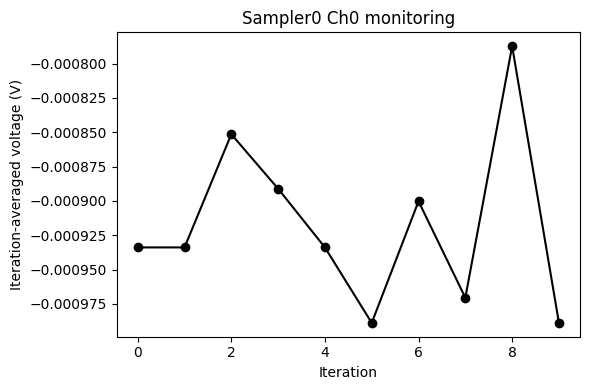

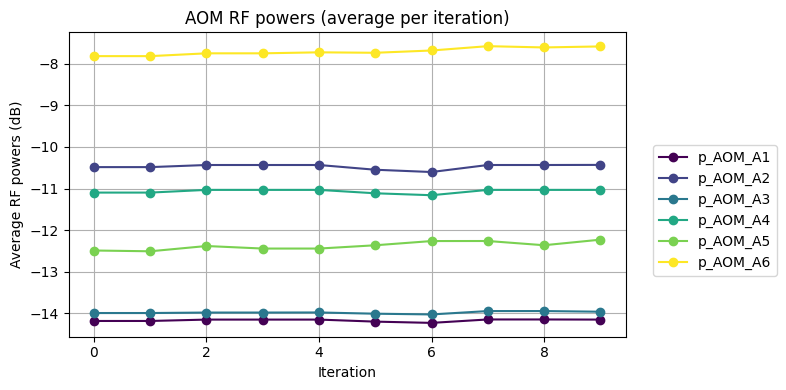

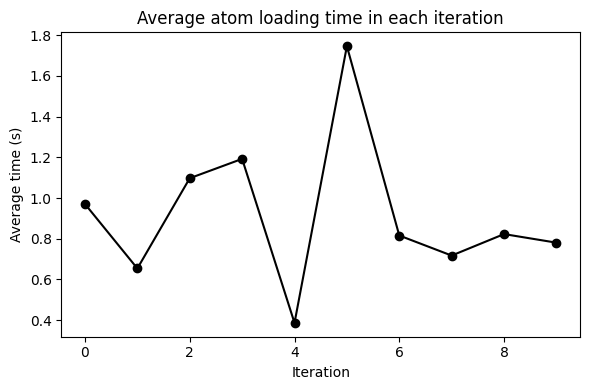

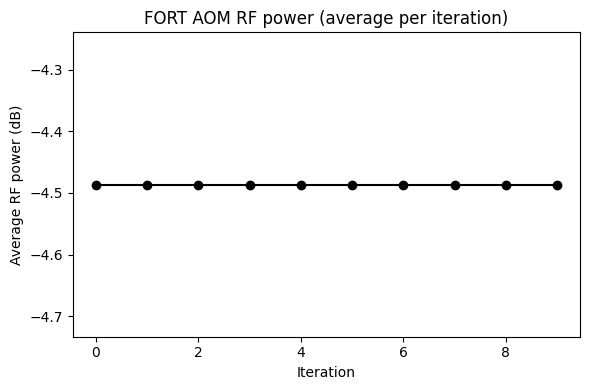

In [5]:
"""
Calculating and plotting the iteration averaged RF powers to the AOMs, along with the atom loading time. This requires n_feedback_per_iteration 
and n_atom_loaded_per_iteration datasets which are generated in some experiments.

The goal is to see if there is any correlation between bad atom loading (averaged over an iteration) and RF values (averaged over an iteration). 
This would indicate a Sampler issue, for example.

n_feedback_per_iteration[1:] = [2,2,3,2,5,...], with len()=iteration, shows the number of times the feedback ran in each iteration. Therefore, it is used to 
splice the RF power arrays, like p_AOM_A1_history, into subarrays for each iteration (first subarray for the first iteration, etc.).
"""

######## Splice the sampler testing array and average over each iteration
Sampler0_ch0_iteration_ave = []
start = 0
for i in range(iterations):
    subset = Sampler0_test[1:][i*n_measurements:(i+1)*n_measurements]
    avg = np.mean(subset)
    Sampler0_ch0_iteration_ave.append(avg)

plt.figure(figsize=(6, 4))
plt.plot(Sampler0_ch0_iteration_ave, marker='o', linestyle='-', color='black')
plt.title('Sampler0 Ch0 monitoring')
plt.xlabel('Iteration')
plt.ylabel('Iteration-averaged voltage (V)')
plt.tight_layout()
plt.show()


### Initialize list of suffixes and colors
channel_suffixes = range(1, 7)
colors = plt.cm.viridis(np.linspace(0, 1, len(channel_suffixes)))

plt.figure(figsize=(8, 4))

##### Loop over each channel to splice p_AOM_Ai_history arrays and average
for i, suffix in enumerate(channel_suffixes):
    var_name = f'p_AOM_A{suffix}_history'
    history = globals()[var_name][1:]  # skip the first element
    n_feedback = n_feedback_per_iteration[1:].astype(int)
    
    ### Compute per-iteration averages
    iteration_averages = []
    start = 0
    for count in n_feedback:
        subset = history[start:start+count]
        avg = np.mean(subset)
        iteration_averages.append(avg)
        start += count
    iteration_averages = np.array(iteration_averages)

    plt.plot(iteration_averages, marker='o', linestyle='-',
             color=colors[i], label=f'p_AOM_A{i+1}')

plt.title('AOM RF powers (average per iteration)')
plt.xlabel('Iteration')
plt.ylabel('Average RF powers (dB)')
plt.legend(loc=(1.05, 0.2))
plt.grid(True)
plt.tight_layout()
plt.show()


##### Splice Atom_loading_time array and average
Atom_loading_time_iteration_ave = []
start = 0
for count in n_atom_loaded_per_iteration[1:].astype(int):
    subset = Atom_loading_time[1:][start:start+count]
    avg = np.mean(subset)
    Atom_loading_time_iteration_ave.append(avg)
    start += count

Atom_loading_time_iteration_ave = np.array(Atom_loading_time_iteration_ave)

plt.figure(figsize=(6, 4))
plt.plot(Atom_loading_time_iteration_ave, marker='o', linestyle='-', color='black')
plt.title('Average atom loading time in each iteration')
plt.xlabel('Iteration')
plt.ylabel('Average time (s)')
plt.tight_layout()
plt.show()


###### Splice p_FORT_loading_history array and average
p_FORT_loading_history_iteration_ave = []
start = 0
for count in n_feedback_per_iteration[1:].astype(int):
    subset = p_FORT_loading_history[1:][start:start+count]
    avg = np.mean(subset)
    p_FORT_loading_history_iteration_ave.append(avg)
    start += count

p_FORT_loading_history_iteration_ave = np.array(p_FORT_loading_history_iteration_ave)

plt.figure(figsize=(6, 4))
plt.plot(p_FORT_loading_history_iteration_ave, marker='o', linestyle='-', color='black')
plt.title('FORT AOM RF power (average per iteration)')
plt.xlabel('Iteration')
plt.ylabel('Average RF power (dB)')
plt.tight_layout()
plt.show()



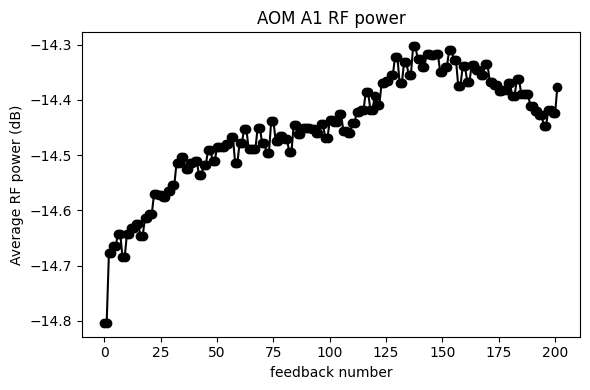

In [282]:
plt.figure(figsize=(6, 4))
plt.plot(p_AOM_A1_history, marker='o', linestyle='-', color='black')
plt.title('AOM A1 RF power')
plt.xlabel('feedback number')
plt.ylabel('Average RF power (dB)')
plt.tight_layout()
plt.show()

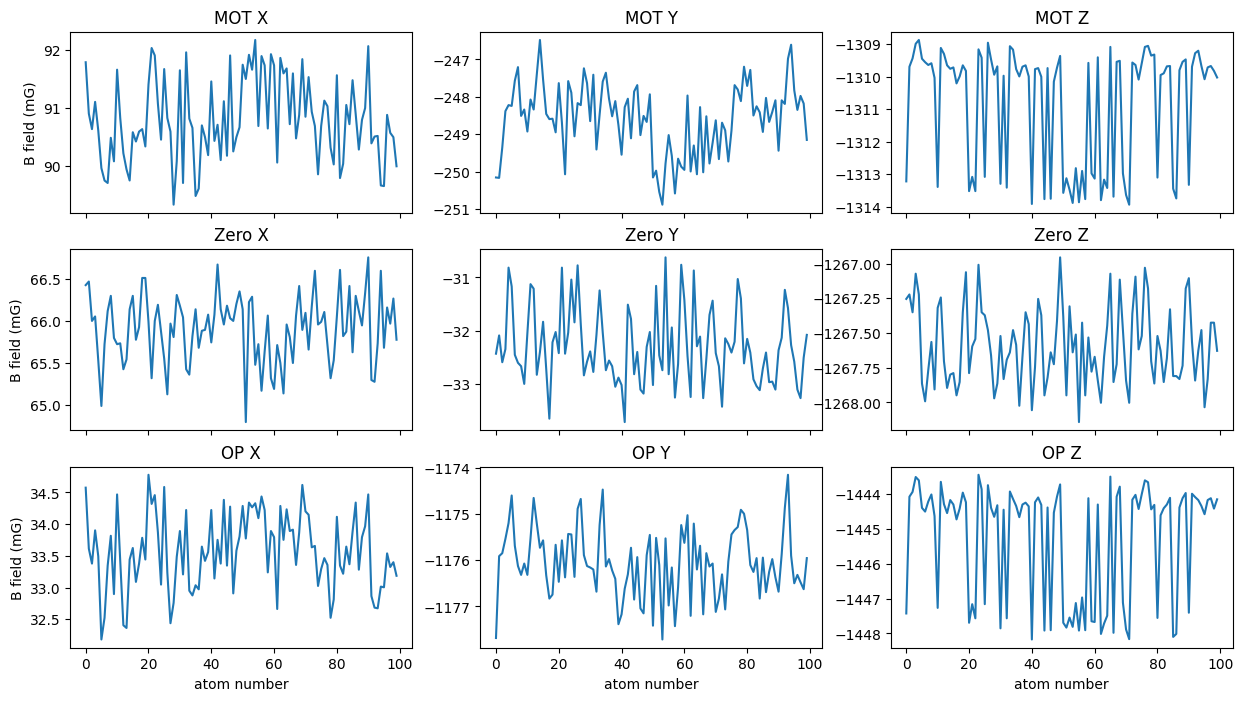

In [7]:
"""
Plotting the magnetometer added to ARTIQ since 2025-04-19.
For all atom loading events. Note that the magneometer is measured in every "measurement", not necessarily when 

"""
fig, axs = plt.subplots(3, 3, figsize=(15, 8), sharey=False, sharex=True)

######## MOT
axs[0, 0].plot(Magnetometer_MOT_X[1:])
axs[0, 0].set_ylabel("B field (mG)")
axs[0, 0].set_title("MOT X")

axs[0, 1].plot(Magnetometer_MOT_Y[1:])
axs[0, 1].set_title("MOT Y")

axs[0, 2].plot(Magnetometer_MOT_Z[1:])
axs[0, 2].set_title("MOT Z");


######## Zero
axs[1, 0].plot(Magnetometer_Zero_X[1:])
axs[1, 0].set_ylabel("B field (mG)")
axs[1, 0].set_title("Zero X")

axs[1, 1].plot(Magnetometer_Zero_Y[1:])
axs[1, 1].set_title("Zero Y")

axs[1, 2].plot(Magnetometer_Zero_Z[1:])
axs[1, 2].set_title("Zero Z");


######## OP
axs[2, 0].plot(Magnetometer_OP_X[1:])
axs[2, 0].set_xlabel("atom number")
axs[2, 0].set_ylabel("B field (mG)")
axs[2, 0].set_title("OP X")

axs[2, 1].plot(Magnetometer_OP_Y[1:])
axs[2, 1].set_xlabel("atom number")
axs[2, 1].set_title("OP Y")

axs[2, 2].plot(Magnetometer_OP_Z[1:])
axs[2, 2].set_xlabel("atom number")
axs[2, 2].set_title("OP Z");





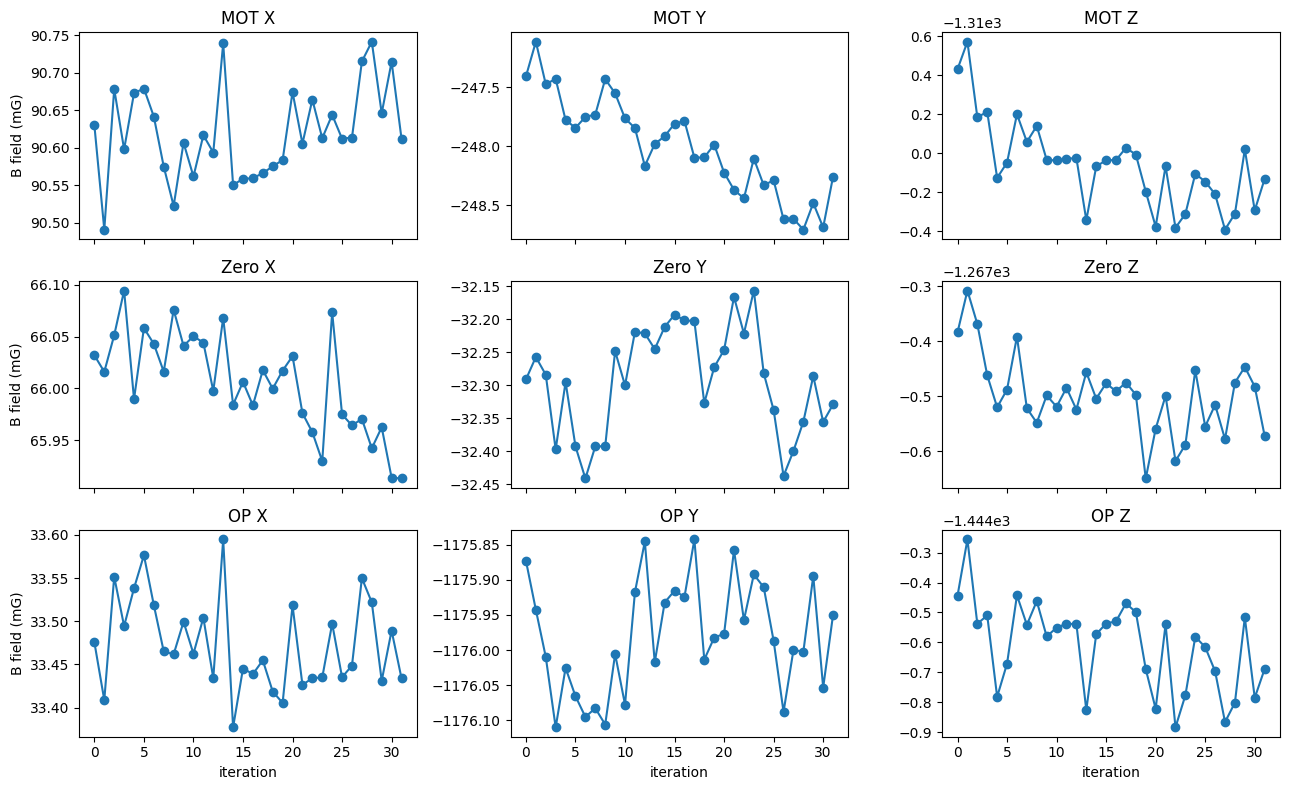

In [242]:
"""
Plotting the magnetometer averaged in each iteration.
For all atom loading events. Note that the magneometer is measured in every "measurement", not necessarily when we load an atom. 

"""

######## Splice the magnetometer data array and average over each iteration
Magnetometer_data = [Magnetometer_MOT_X[1:], Magnetometer_MOT_Y[1:], Magnetometer_MOT_Z[1:], 
                     Magnetometer_Zero_X[1:], Magnetometer_Zero_Y[1:], Magnetometer_Zero_Z[1:],
                     Magnetometer_OP_X[1:], Magnetometer_OP_Y[1:], Magnetometer_OP_Z[1:]]

Magnetometer_data_iteration_ave = [[] for _ in range(len(Magnetometer_data))]

for d in range(len(Magnetometer_data)):
    start = 0
    for i in range(iterations):
        subset = Magnetometer_data[d][i*n_measurements:(i+1)*n_measurements]
        avg = np.mean(subset)
        Magnetometer_data_iteration_ave[d].append(avg)



fig, axs = plt.subplots(3, 3, figsize=(13, 8), sharey=False, sharex=True)
titles = [
    "MOT X", "MOT Y", "MOT Z",
    "Zero X", "Zero Y", "Zero Z",
    "OP X", "OP Y", "OP Z"
]

# ylabels = ["B field (mG)"] * 3 + ["B field (mG)"] * 3 + ["B field (mG)"] * 3
ylabels = ["B field (mG)"] + [""]*2 + ["B field (mG)"] + [""]*2 + ["B field (mG)"] + [""]*2
xlabels = [""] * 6 + ["iteration"] * 3  # Only bottom row gets x-axis labels

for idx, avg_data in enumerate(Magnetometer_data_iteration_ave):
    row = idx // 3
    col = idx % 3
    ax = axs[row, col]
    
    ax.plot(avg_data, marker='o')  # add markers for clarity
    ax.set_title(titles[idx])
    
    if ylabels[idx]:
        ax.set_ylabel(ylabels[idx])
    if xlabels[idx]:
        ax.set_xlabel(xlabels[idx])

plt.tight_layout()
plt.show()


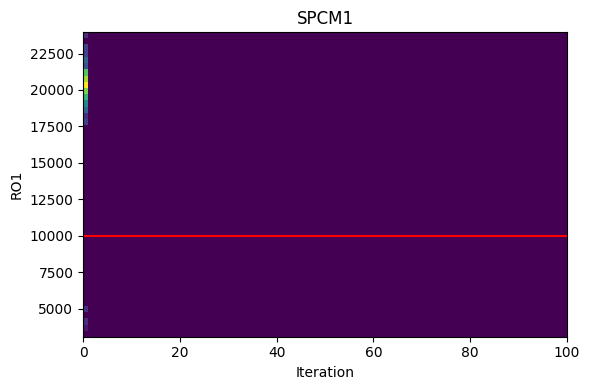

In [231]:
"""
Slicing SPCM1_RO1 into more sections to see the readout fluctuation over time in more details. 

"""

n = 100
ii = 100
SPCM1_RO1_hists = []
SPCM1_RO1_hists.append(
            [np.histogram(SPCM1_RO1[i*n:(i+1)*n]/t_SPCM_first_shot,bins=np.linspace(histMin,histMax,50))[0]
                              for i in range(ii)])

hist_data = np.array(SPCM1_RO1_hists[0]).T  # shape: [bins, ii]

plt.figure(figsize=(6, 4))
plt.imshow(hist_data, origin='lower', extent=[0, ii, histMin, histMax], aspect='auto')

# Add horizontal line at the cutoff
plt.axhline(cutoff1 / t_SPCM_first_shot, color='red')

# Axis labels and title
plt.xlabel("Iteration")
plt.ylabel("RO1")
plt.title("SPCM1")

plt.tight_layout()
plt.show()

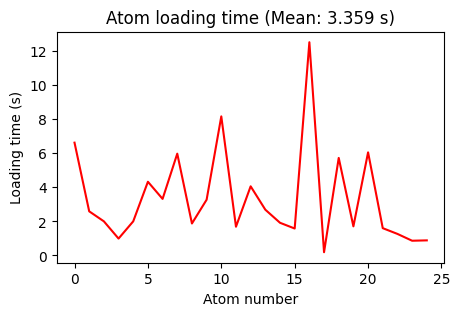

In [232]:
#######  Atom loading time plot
## We can slice the array to separate iterations later, if we want.

data = Atom_loading_time[10:]

mean_loading_time = np.mean(data)  
plt.figure(figsize=(5, 3))
plt.plot(data, 'r-')

plt.xlabel("Atom number")
plt.ylabel("Loading time (s)")
plt.title(f"Atom loading time (Mean: {mean_loading_time:.3f} s)") 
plt.show()